In [ ]:
!pip install pandas networkx tqdm dgl
print("Installing node2vec for DeepWalk baseline...")
!pip install node2vec
print("node2vec installed.")
!pip install python-louvain

Installing node2vec for DeepWalk baseline...
node2vec installed.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install torch_scatter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torch_scatter: filename=torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl size=677289 sha256=240b6e5530f616bb462e3715a50dbce5d03450d62adbd2f1bfc7cc134bfa770f
  Stored in directory: /root/.cache/pip/wheels/84/20/50/44800723f57cd798630e77b3ec83bc80bd26a1e3dc3a672ef5
Successfully built torch_scatter


In [ ]:
import pandas as pd

ml_100k_path = "/content/drive/MyDrive/ml-100k/"

item_cols = (['movie_id', 'movie_title', 'release_date', 'video_release_date', 'imdb_url'] +
            ['unknown', 'Action', 'Adventure', 'Animation', 'Childrens', 'Comedy', 'Crime',
             'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
             'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'])

movies_100k_df = pd.read_csv(ml_100k_path + 'u.item', sep='|', encoding='latin-1', header=None, names=item_cols)
print("u.item (Movies DataFrame) Head:")
display(movies_100k_df.head())


user_cols = ['user_id', 'age', 'gender', 'occupation', 'zip_code']
users_100k_df = pd.read_csv(ml_100k_path + 'u.user', sep='|', encoding='latin-1', header=None, names=user_cols)
print("\nu.user (Users DataFrame) Head:")
display(users_100k_df.head())


ratings_100k_df = pd.read_csv(ml_100k_path + 'u.data', sep='\t', header=None, names=['user_id', 'item_id', 'rating', 'timestamp'])
print("\nu.data (Ratings DataFrame) Head:")
display(ratings_100k_df.head())

print(f"\nShape of movies_100k_df: {movies_100k_df.shape}")
print(f"Shape of users_100k_df: {users_100k_df.shape}")
print(f"Shape of ratings_100k_df: {ratings_100k_df.shape}")


u.item (Movies DataFrame) Head:


,movie_id,movie_title,release_date,video_release_date,imdb_url,unknown,Action,Adventure,Animation,Childrens,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0



u.user (Users DataFrame) Head:


,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213



u.data (Ratings DataFrame) Head:


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596



Shape of movies_100k_df: (1682, 24)
Shape of users_100k_df: (943, 5)
Shape of ratings_100k_df: (100000, 4)


In [ ]:
genre_file_path = ml_100k_path + 'u.genre'

genre_cols = ['genre', 'genre_id']
genres_df = pd.read_csv(genre_file_path, sep='|', header=None, encoding='latin-1', names=genre_cols)

print("u.genre (Genres DataFrame) Head:")
display(genres_df.head())

print("\nFull u.genre (Genres DataFrame):")
display(genres_df)

u.genre (Genres DataFrame) Head:


,genre,genre_id
0,unknown,0
1,Action,1
2,Adventure,2
3,Animation,3
4,Children's,4



Full u.genre (Genres DataFrame):


,genre,genre_id
0,unknown,0
1,Action,1
2,Adventure,2
3,Animation,3
4,Children's,4
5,Comedy,5
6,Crime,6
7,Documentary,7
8,Drama,8
9,Fantasy,9


## Initialize Graph and Add All Node Types

Initialize a NetworkX MultiDiGraph and add 'user', 'movie', and 'genre' nodes with their respective attributes.


In [ ]:
import networkx as nx

# 2. Initialize an empty MultiDiGraph object
G = nx.MultiDiGraph()

# 3. Add 'user' nodes with attributes
for index, row in users_100k_df.iterrows():
    user_id = row['user_id']
    G.add_node(f"user_{user_id}",
               node_type='user',
               user_id=user_id,
               age=row['age'],
               gender=row['gender'],
               occupation=row['occupation'],
               zip_code=row['zip_code'])

# 4. Add 'movie' nodes with attributes
genre_columns = ['Action', 'Adventure', 'Animation', 'Childrens', 'Comedy', 'Crime',
                 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
                 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

for index, row in movies_100k_df.iterrows():
    movie_id = row['movie_id']
    movie_title = row['movie_title']

    # Extract genres for the movie
    movie_genres = []
    for genre_col in genre_columns:
        if row[genre_col] == 1:
            movie_genres.append(genre_col)

    genres_string = ",".join(movie_genres)

    G.add_node(f"movie_{movie_id}",
               node_type='movie',
               movie_id=movie_id,
               movie_title=movie_title,
               genres=genres_string)

# 5. Add 'genre' nodes
# Extract unique genre names from the genres_df DataFrame, excluding 'unknown'
unique_genres = genres_df[genres_df['genre'] != 'unknown']['genre'].tolist()

for genre_name in unique_genres:
    G.add_node(f"genre_{genre_name}",
               node_type='genre',
               genre_name=genre_name)

print(f"Graph initialized with {G.number_of_nodes()} nodes.")
print(f"Number of user nodes: {len([node for node, data in G.nodes(data=True) if data['node_type'] == 'user'])}")
print(f"Number of movie nodes: {len([node for node, data in G.nodes(data=True) if data['node_type'] == 'movie'])}")
print(f"Number of genre nodes: {len([node for node, data in G.nodes(data=True) if data['node_type'] == 'genre'])}")

Graph initialized with 2643 nodes.
Number of user nodes: 943
Number of movie nodes: 1682
Number of genre nodes: 18


## Add Inter-Layer Edges

Add inter-layer edges to the graph:
1.  **User-Movie Edges (Ratings)**: Iterate through the `ratings_100k_df` DataFrame to add edges between user nodes and movie nodes. Each edge should represent a rating, with the `rating` and `timestamp` as attributes.
2.  **Movie-Genre Edges**: Iterate through the `movies_100k_df` DataFrame. For each movie, extract its genres (using the genre columns) and add edges between the movie node and its corresponding genre nodes. These edges should indicate that the movie 'has_genre' with 'genre' as the edge type.

In [ ]:
print("Adding inter-layer edges...")

# 1. Add 'rates' edges between user and movie nodes
for index, row in ratings_100k_df.iterrows():
    user_id = row['user_id']
    movie_id = row['item_id']
    rating = row['rating']
    timestamp = row['timestamp']
    G.add_edge(f"user_{user_id}", f"movie_{movie_id}",
               edge_type='rates',
               rating=rating,
               timestamp=timestamp)

# 2. Add 'has_genre' edges between movie and genre nodes
genre_columns = ['Action', 'Adventure', 'Animation', 'Childrens', 'Comedy', 'Crime',
                 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
                 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

for index, row in movies_100k_df.iterrows():
    movie_id = row['movie_id']

    # Extract genres for the movie
    for genre_col in genre_columns:
        if row[genre_col] == 1: # If the movie belongs to this genre
            genre_name = genre_col
            G.add_edge(f"movie_{movie_id}", f"genre_{genre_name}",
                       edge_type='has_genre')

print(f"Total number of edges in the graph: {G.number_of_edges()}")
print(f"Number of 'rates' edges: {sum(1 for u,v,d in G.edges(data=True) if d.get('edge_type') == 'rates')}")
print(f"Number of 'has_genre' edges: {sum(1 for u,v,d in G.edges(data=True) if d.get('edge_type') == 'has_genre')}")

Adding inter-layer edges...
Total number of edges in the graph: 102891
Number of 'rates' edges: 100000
Number of 'has_genre' edges: 2891


## Add Intra-Layer Edges


Add intra-layer edges to the graph:
1.  **User-User Similarity Edges**: Iterate through all pairs of user nodes. If two users have rated at least one common movie, calculate a similarity score (e.g., Pearson correlation or cosine similarity) based on their common movie ratings. Add an edge between these user nodes with the calculated similarity score as an attribute.
2.  **Movie-Movie Similarity Edges**: Iterate through all pairs of movie nodes. If two movies share at least one common genre, add an edge between these movie nodes with 'shares_genre' as the edge type.

In [ ]:
import numpy as np
from scipy.stats import pearsonr

# Create a user-movie ratings matrix for similarity calculation
user_movie_ratings = ratings_100k_df.pivot(index='user_id', columns='item_id', values='rating')

print("User-movie ratings matrix head:")
display(user_movie_ratings.head())

print(f"Shape of user-movie ratings matrix: {user_movie_ratings.shape}")

User-movie ratings matrix head:


item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Shape of user-movie ratings matrix: (943, 1682)


In [ ]:
print("Adding intra-layer user-user similarity edges...")

# Get all user IDs from the DataFrame
user_ids = user_movie_ratings.index.tolist()

# Iterate through all unique pairs of users
for i in range(len(user_ids)):
    for j in range(i + 1, len(user_ids)):
        user1_id = user_ids[i]
        user2_id = user_ids[j]

        # Get ratings for both users
        user1_ratings = user_movie_ratings.loc[user1_id]
        user2_ratings = user_movie_ratings.loc[user2_id]

        # Find common rated movies (where both users have a rating)
        common_movies = user1_ratings.dropna().index.intersection(user2_ratings.dropna().index)

        if len(common_movies) > 1:  # Pearson correlation requires at least 2 common data points
            # Extract ratings for common movies
            user1_common_ratings = user1_ratings[common_movies]
            user2_common_ratings = user2_ratings[common_movies]

            # Check if either array is constant before calculating Pearson correlation
            # If an array is constant, Pearson correlation is undefined, and pearsonr would raise a warning.
            if user1_common_ratings.nunique() <= 1 or user2_common_ratings.nunique() <= 1:
                similarity = np.nan
            else:
                # Calculate Pearson correlation
                # pearsonr returns (correlation, p-value), we only need correlation
                similarity, _ = pearsonr(user1_common_ratings, user2_common_ratings)

            # Add an edge if similarity is not NaN (can happen if std dev is 0 for one user's ratings)
            if not np.isnan(similarity):
                G.add_edge(f"user_{user1_id}", f"user_{user2_id}",
                           edge_type='user_similarity',
                           similarity=similarity)
                G.add_edge(f"user_{user2_id}", f"user_{user1_id}",
                           edge_type='user_similarity',
                           similarity=similarity)

print(f"Number of 'user_similarity' edges: {sum(1 for u,v,d in G.edges(data=True) if d.get('edge_type') == 'user_similarity')}")
print(f"Total number of edges after adding user similarities: {G.number_of_edges()}")

Adding intra-layer user-user similarity edges...
Number of 'user_similarity' edges: 765474
Total number of edges after adding user similarities: 868365


In [ ]:
print("Adding intra-layer movie-movie similarity edges...")

# Get all movie IDs from the DataFrame
movie_ids = movies_100k_df['movie_id'].tolist()

# Iterate through all unique pairs of movies
for i in range(len(movie_ids)):
    for j in range(i + 1, len(movie_ids)):
        movie1_id = movie_ids[i]
        movie2_id = movie_ids[j]

        # Get genre information for both movies
        movie1_genres_str = G.nodes[f"movie_{movie1_id}"]['genres']
        movie2_genres_str = G.nodes[f"movie_{movie2_id}"]['genres']

        # Convert genre strings to sets for easy comparison
        movie1_genres = set(movie1_genres_str.split(',')) if movie1_genres_str else set()
        movie2_genres = set(movie2_genres_str.split(',')) if movie2_genres_str else set()

        # Find common genres
        common_genres = movie1_genres.intersection(movie2_genres)

        if len(common_genres) > 0:  # If they share at least one genre
            G.add_edge(f"movie_{movie1_id}", f"movie_{movie2_id}",
                       edge_type='shares_genre')
            G.add_edge(f"movie_{movie2_id}", f"movie_{movie1_id}",
                       edge_type='shares_genre')

print(f"Number of 'shares_genre' edges: {sum(1 for u,v,d in G.edges(data=True) if d.get('edge_type') == 'shares_genre')}")
print(f"Total number of edges after adding movie similarities: {G.number_of_edges()}")

Adding intra-layer movie-movie similarity edges...
Number of 'shares_genre' edges: 979580
Total number of edges after adding movie similarities: 1847945


## Verify Graph Structure and Statistics

Verify the structure and statistics of the created heterogeneous graph by:
1.  Printing the total number of nodes and edges in the graph.
2.  Printing the count of each node type ('user', 'movie', 'genre').
3.  Printing the count of each edge type ('rates', 'has_genre', 'user_similarity', 'shares_genre').
4.  Displaying a sample of node attributes for each node type (e.g., one user node, one movie node, one genre node).
5.  Displaying a sample of edge attributes for each edge type (e.g., one 'rates' edge, one 'user_similarity' edge, one 'has_genre' edge, one 'shares_genre' edge).

In [ ]:
print("\n--- Graph Verification ---")

# 1. Total number of nodes and edges
print(f"Total number of nodes in the graph: {G.number_of_nodes()}")
print(f"Total number of edges in the graph: {G.number_of_edges()}")

# 2. Count of each node type
user_nodes_count = sum(1 for node, data in G.nodes(data=True) if data.get('node_type') == 'user')
movie_nodes_count = sum(1 for node, data in G.nodes(data=True) if data.get('node_type') == 'movie')
genre_nodes_count = sum(1 for node, data in G.nodes(data=True) if data.get('node_type') == 'genre')
print(f"Number of user nodes: {user_nodes_count}")
print(f"Number of movie nodes: {movie_nodes_count}")
print(f"Number of genre nodes: {genre_nodes_count}")

# 3. Count of each edge type
rates_edges_count = sum(1 for u, v, d in G.edges(data=True) if d.get('edge_type') == 'rates')
has_genre_edges_count = sum(1 for u, v, d in G.edges(data=True) if d.get('edge_type') == 'has_genre')
user_similarity_edges_count = sum(1 for u, v, d in G.edges(data=True) if d.get('edge_type') == 'user_similarity')
shares_genre_edges_count = sum(1 for u, v, d in G.edges(data=True) if d.get('edge_type') == 'shares_genre')

print(f"Number of 'rates' edges: {rates_edges_count}")
print(f"Number of 'has_genre' edges: {has_genre_edges_count}")
print(f"Number of 'user_similarity' edges: {user_similarity_edges_count}")
print(f"Number of 'shares_genre' edges: {shares_genre_edges_count}")

# 4. Sample node attributes
print("\n--- Sample Node Attributes ---")
sample_user_node = next(iter(node for node, data in G.nodes(data=True) if data.get('node_type') == 'user'), None)
if sample_user_node: print(f"Sample User Node: {G.nodes[sample_user_node]}")

sample_movie_node = next(iter(node for node, data in G.nodes(data=True) if data.get('node_type') == 'movie'), None)
if sample_movie_node: print(f"Sample Movie Node: {G.nodes[sample_movie_node]}")

sample_genre_node = next(iter(node for node, data in G.nodes(data=True) if data.get('node_type') == 'genre'), None)
if sample_genre_node: print(f"Sample Genre Node: {G.nodes[sample_genre_node]}")

# 5. Sample edge attributes
print("\n--- Sample Edge Attributes ---")
sample_rates_edge = next(iter((u, v, d) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'rates'), None)
if sample_rates_edge: print(f"Sample 'rates' Edge: {sample_rates_edge}")

sample_has_genre_edge = next(iter((u, v, d) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'has_genre'), None)
if sample_has_genre_edge: print(f"Sample 'has_genre' Edge: {sample_has_genre_edge}")

sample_user_similarity_edge = next(iter((u, v, d) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'user_similarity'), None)
if sample_user_similarity_edge: print(f"Sample 'user_similarity' Edge: {sample_user_similarity_edge}")

sample_shares_genre_edge = next(iter((u, v, d) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'shares_genre'), None)
if sample_shares_genre_edge: print(f"Sample 'shares_genre' Edge: {sample_shares_genre_edge}")


--- Graph Verification ---
Total number of nodes in the graph: 2644
Total number of edges in the graph: 1847945
Number of user nodes: 943
Number of movie nodes: 1682
Number of genre nodes: 18
Number of 'rates' edges: 100000
Number of 'has_genre' edges: 2891
Number of 'user_similarity' edges: 765474
Number of 'shares_genre' edges: 979580

--- Sample Node Attributes ---
Sample User Node: {'node_type': 'user', 'user_id': 1, 'age': 24, 'gender': 'M', 'occupation': 'technician', 'zip_code': '85711'}
Sample Movie Node: {'node_type': 'movie', 'movie_id': 1, 'movie_title': 'Toy Story (1995)', 'genres': 'Animation,Childrens,Comedy'}
Sample Genre Node: {'node_type': 'genre', 'genre_name': 'Action'}

--- Sample Edge Attributes ---
Sample 'rates' Edge: ('user_1', 'movie_61', {'edge_type': 'rates', 'rating': 4, 'timestamp': 878542420})
Sample 'has_genre' Edge: ('movie_1', 'genre_Animation', {'edge_type': 'has_genre'})
Sample 'user_similarity' Edge: ('user_1', 'user_2', {'edge_type': 'user_similari

In [ ]:
!pip install sentence-transformers

import torch
import torch.nn as nn
import pandas as pd
from sentence_transformers import SentenceTransformer

print("Required libraries installed and imported successfully.")

Required libraries installed and imported successfully.


## Define MLPEncoder Class

### Subtask:
Define a simple `MLPEncoder` class using `torch.nn.Module`. This MLP will take a numeric or one-hot encoded feature vector and transform it into a desired embedding dimension. It should include a few linear layers with activation functions.


In [ ]:
class MLPEncoder(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=64):
        super(MLPEncoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

print("MLPEncoder class defined successfully.")

MLPEncoder class defined successfully.


## Initialize Text Embedder (SentenceTransformer)

### Subtask:
Load a pre-trained `SentenceTransformer` model (e.g., 'all-MiniLM-L6-v2') to encode textual data like movie titles and genre names into dense vector representations. This model will be reused for both movie titles and genre names.


In [ ]:
print("Initializing SentenceTransformer model...")
text_embedder = SentenceTransformer('all-MiniLM-L6-v2')
print("SentenceTransformer model 'all-MiniLM-L6-v2' loaded successfully.")

Initializing SentenceTransformer model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer model 'all-MiniLM-L6-v2' loaded successfully.


In [ ]:
def get_text_embeddings(texts):
    """Encodes a list of texts into embeddings using the pre-trained SentenceTransformer model."""
    # Ensure texts is a list for batch processing
    if isinstance(texts, str):
        texts = [texts]

    # Encode the texts
    embeddings = text_embedder.encode(texts, convert_to_tensor=True)
    return embeddings

print("Function 'get_text_embeddings' defined successfully.")

Function 'get_text_embeddings' defined successfully.


## Encode User Node Attributes

### Subtask:
Extract `age`, `gender`, `occupation`, and `zip_code` from `users_100k_df`. Convert `age` to a numerical tensor and pass it through the `MLPEncoder`. One-hot encode `gender`, `occupation`, and `zip_code` using `pd.get_dummies` and also pass these through the `MLPEncoder` to create embeddings. Concatenate all resulting embeddings to form `user_features`.


In [ ]:
print("Encoding user node attributes...")

# 1. Define a consistent feature_embedding_dim
feature_embedding_dim = 64

# 2. Age Embedding
age_data = torch.tensor(users_100k_df['age'].values, dtype=torch.float32).unsqueeze(1)
age_encoder = MLPEncoder(input_dim=1, output_dim=feature_embedding_dim)
age_embeddings = age_encoder(age_data)

# 3. Gender Embedding
gender_one_hot = pd.get_dummies(users_100k_df['gender'], prefix='gender').astype(int)
gender_data = torch.tensor(gender_one_hot.values, dtype=torch.float32)
gender_encoder = MLPEncoder(input_dim=gender_one_hot.shape[1], output_dim=feature_embedding_dim)
gender_embeddings = gender_encoder(gender_data)

# 4. Occupation Embedding
occupation_one_hot = pd.get_dummies(users_100k_df['occupation'], prefix='occupation').astype(int)
occupation_data = torch.tensor(occupation_one_hot.values, dtype=torch.float32)
occupation_encoder = MLPEncoder(input_dim=occupation_one_hot.shape[1], output_dim=feature_embedding_dim)
occupation_embeddings = occupation_encoder(occupation_data)

# 5. Zip Code Embedding
# For zip_code, directly use get_dummies without prefix for potentially cleaner names
zip_code_one_hot = pd.get_dummies(users_100k_df['zip_code'], prefix='zip_code').astype(int)
zip_code_data = torch.tensor(zip_code_one_hot.values, dtype=torch.float32)
zip_code_encoder = MLPEncoder(input_dim=zip_code_one_hot.shape[1], output_dim=feature_embedding_dim)
zip_code_embeddings = zip_code_encoder(zip_code_data)

# 6. Concatenate all embeddings
user_features = torch.cat([
    age_embeddings,
    gender_embeddings,
    occupation_embeddings,
    zip_code_embeddings
], dim=1)

# 7. Print the shape of user_features
print(f"Shape of user_features: {user_features.shape}")
print("User node attributes encoded and concatenated successfully.")

Encoding user node attributes...
Shape of user_features: torch.Size([943, 256])
User node attributes encoded and concatenated successfully.


## Encode Movie Node Attributes

### Subtask:
Extract genre information from `movies_100k_df` and create multi-hot encoded genre features. Encode `movie_title` using the initialized `SentenceTransformer` model. Concatenate these multi-hot genre features and title embeddings to form `movie_features`.


In [ ]:
print("Encoding movie node attributes...")

# 1. Extract multi-hot encoded genre features
genre_columns = ['Action', 'Adventure', 'Animation', 'Childrens', 'Comedy', 'Crime',
                 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
                 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
movie_genre_one_hot = movies_100k_df[genre_columns].values
movie_genre_data = torch.tensor(movie_genre_one_hot, dtype=torch.float32)

# 2. Instantiate MLPEncoder for genre features
genre_encoder = MLPEncoder(input_dim=len(genre_columns), output_dim=feature_embedding_dim)

# 3. Pass genre features through MLPEncoder
movie_genre_embeddings = genre_encoder(movie_genre_data)

# 4. Extract movie titles
movie_titles = movies_100k_df['movie_title'].tolist()

# 5. Encode movie titles using SentenceTransformer
movie_title_embeddings = get_text_embeddings(movie_titles)

# 6. Concatenate genre embeddings and title embeddings
movie_features = torch.cat([
    movie_genre_embeddings,
    movie_title_embeddings
], dim=1)

# 7. Print the shape of movie_features
print(f"Shape of movie_features: {movie_features.shape}")
print("Movie node attributes encoded and concatenated successfully.")

Encoding movie node attributes...
Shape of movie_features: torch.Size([1682, 448])
Movie node attributes encoded and concatenated successfully.


## Encode Genre Node Attributes

### Subtask:
Extract `genre_name` from `genres_df`. Encode these genre names using the `SentenceTransformer` model to create `genre_features`.


In [ ]:
print("Encoding genre node attributes...")

# 1. Extract genre names from the genres_df DataFrame
genre_names = genres_df['genre'].tolist()

# 2. Encode genre names using the SentenceTransformer model
genre_features = get_text_embeddings(genre_names)

# 3. Print the shape of the resulting genre_features tensor
print(f"Shape of genre_features: {genre_features.shape}")
print("Genre node attributes encoded successfully.")

Encoding genre node attributes...
Shape of genre_features: torch.Size([19, 384])
Genre node attributes encoded successfully.


## Normalize and Consolidate Features

### Subtask:
Ensure that the generated `user_features`, `movie_features`, and `genre_features` are normalized (e.g., L2 normalization) if necessary and are in a consistent format (e.g., PyTorch tensors). Print the shapes of the final feature matrices to verify.


In [ ]:
import torch.nn.functional as F

print("Normalizing feature tensors...")

# Apply L2 normalization to user_features
user_features = F.normalize(user_features, p=2, dim=1)
print(f"Shape of normalized user_features: {user_features.shape}")

# Apply L2 normalization to movie_features
movie_features = F.normalize(movie_features, p=2, dim=1)
print(f"Shape of normalized movie_features: {movie_features.shape}")

# Apply L2 normalization to genre_features
genre_features = F.normalize(genre_features, p=2, dim=1)
print(f"Shape of normalized genre_features: {genre_features.shape}")

print("Feature tensors normalized successfully.")

Normalizing feature tensors...
Shape of normalized user_features: torch.Size([943, 256])
Shape of normalized movie_features: torch.Size([1682, 448])
Shape of normalized genre_features: torch.Size([19, 384])
Feature tensors normalized successfully.


# Task
**Prepare Timestamps for Temporal Encoding**

Extract `timestamp` information from the `ratings_100k_df` and determine a suitable reference point (e.g., the maximum timestamp in the dataset) to calculate recency for all 'rates' edges. This step will prepare the raw temporal data for encoding into a useful feature.

## Prepare Timestamps for Temporal Encoding

### Subtask:
Extract `timestamp` information from the `ratings_100k_df` and determine a suitable reference point (e.g., the maximum timestamp in the dataset) to calculate recency for all 'rates' edges. This step will prepare the raw temporal data for encoding into a useful feature.


In [ ]:
print("Extracting timestamps and finding the maximum timestamp...")

# 1. Extract the 'timestamp' column
timestamps = ratings_100k_df['timestamp']

# 2. Find the maximum timestamp value
max_timestamp = timestamps.max()

print(f"Maximum timestamp found: {max_timestamp}")
print("Timestamps extracted and maximum timestamp identified successfully.")

Extracting timestamps and finding the maximum timestamp...
Maximum timestamp found: 893286638
Timestamps extracted and maximum timestamp identified successfully.


## Define Temporal Encoding Function

### Subtask:
Create a Python function that takes a raw timestamp (or a time difference) and converts it into a temporal feature. This can involve calculating recency relative to a maximum timestamp, and optionally applying a transformation like an exponential decay to emphasize recent interactions, or mapping it to a continuous embedding space using an MLP or sinusoidal functions. The output will be a tensor representing the temporal aspect of an edge.


In [ ]:
import torch

def temporal_encoding_function(timestamps, max_timestamp, tau=86400 * 30): # tau = 30 days in seconds
    """
    Converts timestamps into a temporal feature using recency and exponential decay.

    Args:
        timestamps (int, float, list, or torch.Tensor): Single timestamp or a batch of timestamps (in seconds).
        max_timestamp (int): The maximum timestamp in the dataset (in seconds).
        tau (float): Decay constant for the exponential decay function (in seconds).
                     Defaults to 30 days (86400 * 30 seconds).

    Returns:
        torch.Tensor: A tensor representing the temporal feature(s).
    """
    # Ensure timestamps are a tensor
    if isinstance(timestamps, (int, float)):
        timestamps = torch.tensor([timestamps], dtype=torch.float32)
    elif isinstance(timestamps, list):
        timestamps = torch.tensor(timestamps, dtype=torch.float32)
    elif not isinstance(timestamps, torch.Tensor):
        raise TypeError("timestamps must be an int, float, list, or torch.Tensor")

    # Convert max_timestamp to a tensor for consistent operations
    max_timestamp_tensor = torch.tensor(max_timestamp, dtype=torch.float32)

    # Calculate recency (time difference from the maximum timestamp)
    # Add a small epsilon to avoid potential issues with recency=0 or division by zero in other contexts
    recency = (max_timestamp_tensor - timestamps) # Recency in seconds

    # Apply exponential decay transformation
    # exp(-recency / tau). Larger recency means smaller (older) temporal feature value.
    # Using torch.exp for element-wise operation.
    temporal_feature = torch.exp(-recency / tau)

    return temporal_feature

print("Temporal encoding function 'temporal_encoding_function' defined successfully.")

Temporal encoding function 'temporal_encoding_function' defined successfully.


## Define RelationType Embedding Layer

### Subtask:
Create a `torch.nn.Embedding` layer to learn embeddings for each unique edge type (e.g., 'rates', 'has_genre', 'user_similarity', 'shares_genre'). This will provide a dense vector representation for the relational context of each edge.


In [ ]:
print("Extracting unique edge types and creating ID mapping...")

# 1. Extract all unique `edge_type` values from the edges in the NetworkX graph G
unique_edge_types = sorted(list(set(d['edge_type'] for u, v, d in G.edges(data=True))))

# 2. Create a dictionary to map each unique `edge_type` string to a unique integer ID
edge_type_to_id = {edge_type: i for i, edge_type in enumerate(unique_edge_types)}

# 3. Determine the total number of unique edge types and define a suitable relation_embedding_dim
num_edge_types = len(unique_edge_types)
relation_embedding_dim = 64 # Chosen dimension for relation embeddings

print(f"Unique edge types: {unique_edge_types}")
print(f"Mapping: {edge_type_to_id}")
print(f"Number of unique edge types: {num_edge_types}")
print(f"Relation embedding dimension: {relation_embedding_dim}")

# 4. Initialize a torch.nn.Embedding layer
relation_type_embedder = torch.nn.Embedding(num_edge_types, relation_embedding_dim)

print("torch.nn.Embedding layer for relation types initialized successfully.")

Extracting unique edge types and creating ID mapping...
Unique edge types: ['has_genre', 'rates', 'shares_genre', 'user_similarity']
Mapping: {'has_genre': 0, 'rates': 1, 'shares_genre': 2, 'user_similarity': 3}
Number of unique edge types: 4
Relation embedding dimension: 64
torch.nn.Embedding layer for relation types initialized successfully.


## Design the RTCA Layer

### Subtask:
Implement a `torch.nn.Module` for the `RelationTimeCoAttentionLayer`. This layer will: 1. Take initial node features, edge types, and temporal features (for 'rates' edges) as input. 2. Learn projections for source node features, destination node features, relation type embeddings, and temporal embeddings. 3. Compute attention scores by combining these projected features for each edge. The temporal decay (from the temporal encoding function) will be integrated into this attention score calculation. 4. Aggregate messages from neighbors to each central node, weighted by the computed attention scores. The aggregation should be relation- and time-aware.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Ensure torch_scatter is installed for aggregation functions
try:
    from torch_scatter import scatter_softmax, scatter_add
    print("torch_scatter imported successfully.")
except ImportError:
    print("torch_scatter not found. Installing...")
    !pip install torch_scatter
    from torch_scatter import scatter_softmax, scatter_add
    print("torch_scatter installed and imported successfully.")

class RelationTimeCoAttentionLayer(nn.Module):
    def __init__(self, src_node_feature_dim, dst_node_feature_dim, relation_embedding_dim,
                 temporal_feature_dim, attention_dim, relation_type_embedder, max_timestamp):
        super(RelationTimeCoAttentionLayer, self).__init__()
        self.attention_dim = attention_dim
        self.relation_type_embedder = relation_type_embedder # Pre-trained embedding layer for relation types
        self.max_timestamp = max_timestamp # Max timestamp for temporal encoding

        # Projections for source node features
        self.proj_src_node = nn.Linear(src_node_feature_dim, attention_dim)
        # Projections for destination node features
        self.proj_dst_node = nn.Linear(dst_node_feature_dim, attention_dim)
        # Projections for relation type embeddings
        self.proj_relation = nn.Linear(relation_embedding_dim, attention_dim)
        # Projections for temporal embeddings
        self.proj_temporal = nn.Linear(temporal_feature_dim, attention_dim)

        # Attention score computation layer: takes concatenated projected features and outputs a single raw score
        self.attn_combine = nn.Linear(attention_dim * 4, 1)
        self.leakyrelu = nn.LeakyReLU(0.2) # Non-linearity for attention scores

    def forward(self, src_node_features_batch, dst_node_features_batch,
                edge_relation_ids_batch, edge_timestamps_batch,
                dst_node_indices_in_full_graph, num_total_nodes):
        """
        Performs a relation- and time-aware co-attention aggregation.

        Args:
            src_node_features_batch (torch.Tensor): Features of source nodes for the batch of edges.
                                                    Shape: (num_edges, src_node_feature_dim)
            dst_node_features_batch (torch.Tensor): Features of destination nodes for the batch of edges.
                                                    Shape: (num_edges, dst_node_feature_dim)
            edge_relation_ids_batch (torch.Tensor): IDs of relation types for the batch of edges.
                                                    Shape: (num_edges,)
            edge_timestamps_batch (torch.Tensor): Timestamps for the batch of edges (used for 'rates' edges).
                                                  Shape: (num_edges,)
            dst_node_indices_in_full_graph (torch.Tensor): Global indices of destination nodes for each edge.
                                                            Shape: (num_edges,)
            num_total_nodes (int): Total number of nodes in the graph, used for aggregation dimension size.

        Returns:
            torch.Tensor: Aggregated relation- and time-aware node embeddings for all nodes.
                          Shape: (num_total_nodes, attention_dim)
        """
        num_edges = src_node_features_batch.shape[0]

        # 1. Learn projections for source node features, destination node features
        proj_src_h = self.proj_src_node(src_node_features_batch) # (num_edges, attention_dim)
        proj_dst_h = self.proj_dst_node(dst_node_features_batch) # (num_edges, attention_dim)

        # 2. Get and project relation type embeddings
        rel_emb = self.relation_type_embedder(edge_relation_ids_batch) # (num_edges, relation_embedding_dim)
        proj_rel_emb = self.proj_relation(rel_emb) # (num_edges, attention_dim)

        # 3. Get and project temporal features
        # Assuming temporal_encoding_function is globally available from a previous step
        temporal_feats = temporal_encoding_function(edge_timestamps_batch, self.max_timestamp) # (num_edges,)
        # Unsqueeze to make it (num_edges, 1) for linear layer input consistency
        proj_temporal_feats = self.proj_temporal(temporal_feats.unsqueeze(1)) # (num_edges, attention_dim)

        # 4. Concatenate projected features for each edge
        combined_features = torch.cat([
            proj_src_h,
            proj_dst_h,
            proj_rel_emb,
            proj_temporal_feats
        ], dim=1) # (num_edges, attention_dim * 4)

        # 5. Compute raw attention scores
        e = self.leakyrelu(self.attn_combine(combined_features)) # (num_edges, 1)

        # 6. Apply softmax to attention scores per destination node
        # The scatter_softmax ensures attention weights sum to 1 for neighbors of each node
        attention_weights = scatter_softmax(e, dst_node_indices_in_full_graph, dim=0) # (num_edges, 1)

        # 7. Aggregate messages: Use projected source features as messages, weighted by attention scores
        # The message content could also be a combination of proj_src_h, proj_rel_emb, proj_temporal_feats
        # For simplicity, we use proj_src_h as the primary message content for now.
        weighted_messages = attention_weights * proj_src_h # (num_edges, attention_dim)

        # 8. Sum messages to destination nodes
        # aggregated_node_embeddings will have shape (num_total_nodes, attention_dim)
        aggregated_node_embeddings = scatter_add(weighted_messages,
                                                 dst_node_indices_in_full_graph,
                                                 dim=0,
                                                 dim_size=num_total_nodes)

        return aggregated_node_embeddings

print("RelationTimeCoAttentionLayer class defined successfully.")


torch_scatter imported successfully.
RelationTimeCoAttentionLayer class defined successfully.


## Define Graph Transformer Network (GTN) Layer

### Subtask:
Implement a `torch.nn.Module` for a Graph Transformer Network (GTN) layer that takes relation-time aggregated embeddings as input and incorporates mechanisms to learn 'soft' adjacency matrices for different meta-paths, using learnable transformation matrices and attention mechanisms to generate meta-path-aware features for nodes.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_scatter import scatter_softmax, scatter_add # Assuming these are already installed/imported

class GTNLayer(nn.Module):
    def __init__(self, in_features, out_features, num_channels, relation_embedding_dim):
        super(GTNLayer, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.num_channels = num_channels
        self.relation_embedding_dim = relation_embedding_dim

        # 1. Node Transformations: A linear layer for each channel
        self.node_transformations = nn.ModuleList([
            nn.Linear(in_features, out_features) for _ in range(num_channels)
        ])

        # 2. Attention Mechanisms: A linear layer for each channel
        # Input to attention will be concatenated [H_src, H_dst, rel_embs]
        attention_input_dim = in_features * 2 + relation_embedding_dim
        self.attention_mechanisms = nn.ModuleList([
            nn.Linear(attention_input_dim, 1) for _ in range(num_channels)
        ])

        self.leakyrelu = nn.LeakyReLU(0.2) # Non-linearity for attention scores

    def forward(self, H, edge_index, edge_type_ids, relation_type_embedder, num_nodes):
        # H: (num_nodes, in_features)
        # edge_index: (2, num_edges)
        # edge_type_ids: (num_edges,)

        src_nodes, dst_nodes = edge_index[0], edge_index[1]

        # Retrieve features for source and destination nodes
        H_src = H[src_nodes] # (num_edges, in_features)
        H_dst = H[dst_nodes] # (num_edges, in_features)

        # Retrieve relation embeddings
        rel_embs = relation_type_embedder(edge_type_ids) # (num_edges, relation_embedding_dim)

        # Concatenate for attention mechanism input
        attn_base_input = torch.cat([H_src, H_dst, rel_embs], dim=1)

        all_channel_features = []

        for k in range(self.num_channels):
            # Apply node transformation for current channel
            # H_transformed_k: (num_nodes, out_features)
            H_transformed_k = self.node_transformations[k](H)

            # Compute raw attention scores for all edges for current channel
            # raw_attention_scores_k: (num_edges, 1)
            raw_attention_scores_k = self.attention_mechanisms[k](attn_base_input)
            raw_attention_scores_k = self.leakyrelu(raw_attention_scores_k)

            # Normalize attention scores (soft adjacency matrix for channel k)
            # attention_weights_k: (num_edges, 1)
            attention_weights_k = scatter_softmax(raw_attention_scores_k, dst_nodes, dim=0)

            # Multiply messages (transformed source features) by attention weights
            # messages_k: (num_edges, out_features)
            messages_k = attention_weights_k * H_transformed_k[src_nodes]

            # Aggregate messages to destination nodes
            # aggregated_features_k: (num_nodes, out_features)
            aggregated_features_k = scatter_add(messages_k, dst_nodes, dim=0, dim_size=num_nodes)

            all_channel_features.append(aggregated_features_k)

        # Concatenate aggregated features from all channels
        # output_features: (num_nodes, out_features * num_channels)
        output_features = torch.cat(all_channel_features, dim=1)

        return output_features

print("GTNLayer class defined successfully.")

GTNLayer class defined successfully.


## Consolidate Node Features and Edge Information

### Subtask:
Consolidate the `user_features`, `movie_features`, and `genre_features` into a single, unified tensor `H` by padding or adjusting dimensions and concatenating them. Create global `edge_index` and `edge_type_ids` tensors from the NetworkX graph `G` that encompass all edge types and their corresponding source and destination node global IDs. Also, create a global `edge_timestamps` tensor that aligns with `edge_index` and contains the raw timestamps for 'rates' edges (or a placeholder for non-'rates' edges), as well as a global `edge_ratings` tensor for 'rates' edges. This will prepare the graph data for batch processing in PyTorch.


In [ ]:
print("Consolidating node features and edge information...")

# 1. Define a consistent node_feature_projection_dim
node_feature_projection_dim = 128

# 2. Initialize MLPEncoder instances for user_features, movie_features, and genre_features
# User features have original dimension of 256
user_mlp_encoder = MLPEncoder(input_dim=user_features.shape[1], output_dim=node_feature_projection_dim)

# Movie features have original dimension of 448
movie_mlp_encoder = MLPEncoder(input_dim=movie_features.shape[1], output_dim=node_feature_projection_dim)

# Genre features have original dimension of 384
genre_mlp_encoder = MLPEncoder(input_dim=genre_features.shape[1], output_dim=node_feature_projection_dim)

# 3. Project user_features, movie_features, and genre_features
projected_user_features = user_mlp_encoder(user_features)
projected_movie_features = movie_mlp_encoder(movie_features)
projected_genre_features = genre_mlp_encoder(genre_features)

print(f"Shape of projected_user_features: {projected_user_features.shape}")
print(f"Shape of projected_movie_features: {projected_movie_features.shape}")
print(f"Shape of projected_genre_features: {projected_genre_features.shape}")

# 4. Create a global mapping from NetworkX node names (present in G) to contiguous integer IDs
# This is the robust way to handle any implicit nodes created by NetworkX.
node_to_global_id = {node_name: i for i, node_name in enumerate(sorted(G.nodes()))}
total_nodes = len(node_to_global_id)

# For verification printing of ID ranges, we need to extract them from the new map.
# This will not necessarily be contiguous blocks for user/movie/genre if nodes are interspersed.
# But it guarantees all nodes in G have an ID.
user_ids_in_map = []
movie_ids_in_map = []
genre_ids_in_map = []

for node_name, global_id in node_to_global_id.items():
    if node_name.startswith("user_"):
        user_ids_in_map.append(global_id)
    elif node_name.startswith("movie_"):
        movie_ids_in_map.append(global_id)
    elif node_name.startswith("genre_"):
        genre_ids_in_map.append(global_id)

if user_ids_in_map:
    print(f"User node IDs range: {min(user_ids_in_map)} to {max(user_ids_in_map)} (Total: {len(user_ids_in_map)})")
else:
    print("No user nodes found in graph G.")

if movie_ids_in_map:
    print(f"Movie node IDs range: {min(movie_ids_in_map)} to {max(movie_ids_in_map)} (Total: {len(movie_ids_in_map)})")
else:
    print("No movie nodes found in graph G.")

if genre_ids_in_map:
    print(f"Genre node IDs range: {min(genre_ids_in_map)} to {max(genre_ids_in_map)} (Total: {len(genre_ids_in_map)})")
else:
    print("No genre nodes found in graph G.")

print(f"Total number of nodes (from G.nodes()): {total_nodes}")

# 5. Initialize a zero tensor H
H = torch.zeros((total_nodes, node_feature_projection_dim))

# 6. Populate H with projected features based on the new global_id mapping
user_id_to_feature_idx = {id: i for i, id in enumerate(users_100k_df['user_id'])}
movie_id_to_feature_idx = {id: i for i, id in enumerate(movies_100k_df['movie_id'])}
genre_name_to_feature_idx = {name: i for i, name in enumerate(genres_df['genre'])}

for node_name, global_id in node_to_global_id.items():
    if node_name.startswith("user_"):
        user_id = int(node_name.split('_')[1])
        if user_id in user_id_to_feature_idx:
            H[global_id] = projected_user_features[user_id_to_feature_idx[user_id]]
    elif node_name.startswith("movie_"):
        movie_id = int(node_name.split('_')[1])
        if movie_id in movie_id_to_feature_idx:
            H[global_id] = projected_movie_features[movie_id_to_feature_idx[movie_id]]
    elif node_name.startswith("genre_"):
        genre_key = node_name.split('genre_')[1]
        if genre_key == "Childrens": # This is the inconsistent name from edges
            # Assign features of "Children's" (the correct name)
            if "Children's" in genre_name_to_feature_idx:
                 H[global_id] = projected_genre_features[genre_name_to_feature_idx["Children's"]]
        elif genre_key in genre_name_to_feature_idx:
            H[global_id] = projected_genre_features[genre_name_to_feature_idx[genre_key]]
        else:
            # Handle other potentially implicitly created genre nodes if necessary,
            # for now, they would remain zero-initialized.
            pass
    # For any other node types or implicitly created nodes not explicitly handled, their features remain zeros.


# 7-11. Iterate through edges to collect information
source_nodes_global_ids = []
dest_nodes_global_ids = []
edge_type_ids_list = []
edge_timestamps_list = []
edge_ratings_list = []

# Placeholder for non-'rates' edges (assuming max_timestamp and 0 rating)
placeholder_timestamp = max_timestamp
placeholder_rating = 0

for u_node, v_node, edge_data in G.edges(data=True):
    src_global_id = node_to_global_id[u_node]
    dst_global_id = node_to_global_id[v_node] # This will no longer raise KeyError
    edge_type_str = edge_data['edge_type']
    edge_type_id = edge_type_to_id[edge_type_str]

    source_nodes_global_ids.append(src_global_id)
    dest_nodes_global_ids.append(dst_global_id)
    edge_type_ids_list.append(edge_type_id)

    if edge_type_str == 'rates':
        edge_timestamps_list.append(edge_data['timestamp'])
        edge_ratings_list.append(edge_data['rating'])
    else:
        edge_timestamps_list.append(placeholder_timestamp)
        edge_ratings_list.append(placeholder_rating)

# 12. Convert collected lists into torch.Tensors
edge_index = torch.tensor([source_nodes_global_ids, dest_nodes_global_ids], dtype=torch.long)
edge_type_ids = torch.tensor(edge_type_ids_list, dtype=torch.long)
edge_timestamps = torch.tensor(edge_timestamps_list, dtype=torch.float32)
edge_ratings = torch.tensor(edge_ratings_list, dtype=torch.float32)

# 13. Print shapes for verification
print(f"\nShape of consolidated node features (H): {H.shape}")
print(f"Shape of edge_index: {edge_index.shape}")
print(f"Shape of edge_type_ids: {edge_type_ids.shape}")
print(f"Shape of edge_timestamps: {edge_timestamps.shape}")
print(f"Shape of edge_ratings: {edge_ratings.shape}")
print("Node features and edge information consolidated successfully.")

Consolidating node features and edge information...
Shape of projected_user_features: torch.Size([943, 128])
Shape of projected_movie_features: torch.Size([1682, 128])
Shape of projected_genre_features: torch.Size([19, 128])
User node IDs range: 1701 to 2643 (Total: 943)
Movie node IDs range: 19 to 1700 (Total: 1682)
Genre node IDs range: 0 to 18 (Total: 19)
Total number of nodes (from G.nodes()): 2644

Shape of consolidated node features (H): torch.Size([2644, 128])
Shape of edge_index: torch.Size([2, 1847945])
Shape of edge_type_ids: torch.Size([1847945])
Shape of edge_timestamps: torch.Size([1847945])
Shape of edge_ratings: torch.Size([1847945])
Node features and edge information consolidated successfully.


In [ ]:
print("\n====================")
print("RTCA -> GTN Pipeline")
print("====================")

import torch

# ------------------------------------------------------------------
# 0. Device setup
# ------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Move main tensors & embedding layer to the chosen device
H = H.to(device)                         # (num_nodes, node_feature_projection_dim)
edge_index = edge_index.to(device)       # (2, num_edges)
edge_type_ids = edge_type_ids.to(device) # (num_edges,)
edge_timestamps = edge_timestamps.to(device) # (num_edges,)
relation_type_embedder = relation_type_embedder.to(device)

num_nodes = H.size(0)
num_edges = edge_index.size(1)
print(f"Total nodes: {num_nodes}")
print(f"Total edges (original): {num_edges}")

# ------------------------------------------------------------------
# 1. (Optional but recommended) Edge sub-sampling to avoid OOM
# ------------------------------------------------------------------
# This is just to keep Colab safe. You can increase max_edges if GPU RAM is large.
max_edges = 300_000  # you can try 500_000 later if memory is fine

if num_edges > max_edges:
    print(f"Sub-sampling edges from {num_edges} to {max_edges} for safety.")
    perm = torch.randperm(num_edges, device=device)[:max_edges]
    edge_index_sub = edge_index[:, perm]
    edge_type_ids_sub = edge_type_ids[perm]
    edge_timestamps_sub = edge_timestamps[perm]
else:
    print("Number of edges is within safe range; using all edges.")
    edge_index_sub = edge_index
    edge_type_ids_sub = edge_type_ids
    edge_timestamps_sub = edge_timestamps

num_edges_sub = edge_index_sub.size(1)
print(f"Edges used in RTCA/GTN: {num_edges_sub}")

# ------------------------------------------------------------------
# 2. Prepare inputs for RTCA
# ------------------------------------------------------------------
# We recompute max_timestamp from the edge_timestamps tensor to avoid NameError
max_timestamp = int(edge_timestamps_sub.max().item())
print(f"max_timestamp (for temporal encoding): {max_timestamp}")

# Edge endpoints
src_nodes = edge_index_sub[0]  # (num_edges_sub,)
dst_nodes = edge_index_sub[1]  # (num_edges_sub,)

# Gather node features for each edge
src_node_features_batch = H[src_nodes]  # (num_edges_sub, feature_dim)
dst_node_features_batch = H[dst_nodes]  # (num_edges_sub, feature_dim)

# ------------------------------------------------------------------
# 3. Instantiate RTCA layer
# ------------------------------------------------------------------
attention_dim = 128         # hidden size inside RTCA
temporal_feature_dim = 1    # temporal_encoding_function returns 1 scalar per edge

rtca_layer = RelationTimeCoAttentionLayer(
    src_node_feature_dim=H.size(1),
    dst_node_feature_dim=H.size(1),
    relation_embedding_dim=relation_embedding_dim,
    temporal_feature_dim=temporal_feature_dim,
    attention_dim=attention_dim,
    relation_type_embedder=relation_type_embedder,
    max_timestamp=max_timestamp
).to(device)

print("RTCA layer created.")

# ------------------------------------------------------------------
# 4. Run RTCA: get relation- & time-aware node embeddings
# ------------------------------------------------------------------
with torch.no_grad():  # no training yet, so disable gradients for speed/safety
    H_rtca = rtca_layer(
        src_node_features_batch=src_node_features_batch,
        dst_node_features_batch=dst_node_features_batch,
        edge_relation_ids_batch=edge_type_ids_sub,
        edge_timestamps_batch=edge_timestamps_sub,
        dst_node_indices_in_full_graph=dst_nodes,
        num_total_nodes=num_nodes
    )

print(f"H_rtca shape (RTCA output): {H_rtca.shape}")
# Expected: (num_nodes, attention_dim) = (num_nodes, 128)

# ------------------------------------------------------------------
# 5. Instantiate GTN layer
# ------------------------------------------------------------------
# GTN input dimension is the RTCA output dimension
gtn_in_features = H_rtca.size(1)   # should be attention_dim (128)
gtn_out_features = 64              # you can tune this
num_channels = 2                   # number of meta-path channels

gtn_layer = GTNLayer(
    in_features=gtn_in_features,
    out_features=gtn_out_features,
    num_channels=num_channels,
    relation_embedding_dim=relation_embedding_dim
).to(device)

print("GTN layer created.")

# ------------------------------------------------------------------
# 6. Run GTN on the RTCA embeddings
# ------------------------------------------------------------------
with torch.no_grad():  # again, just forward pass for now
    H_gtn = gtn_layer(
        H=H_rtca,
        edge_index=edge_index_sub,
        edge_type_ids=edge_type_ids_sub,
        relation_type_embedder=relation_type_embedder,
        num_nodes=num_nodes
    )

print(f"H_gtn shape (GTN output): {H_gtn.shape}")
# Expected: (num_nodes, gtn_out_features * num_channels) = (num_nodes, 64 * 2 = 128)

print("RTCA -> GTN pipeline executed successfully.")



RTCA -> GTN Pipeline
Using device: cpu
Total nodes: 2644
Total edges (original): 1847945
Sub-sampling edges from 1847945 to 300000 for safety.
Edges used in RTCA/GTN: 300000
max_timestamp (for temporal encoding): 893286656
RTCA layer created.
H_rtca shape (RTCA output): torch.Size([2644, 128])
GTN layer created.
H_gtn shape (GTN output): torch.Size([2644, 128])
RTCA -> GTN pipeline executed successfully.


In [ ]:
# ============================================================
# HATCom Lightweight EMA-Based Memory Module (Phase-II)
# ============================================================

class HATComMemoryModule:
    """
    Lightweight EMA-based Temporal Memory Module
    ---------------------------------------------
    Purpose:
    - Stabilize node embeddings across time
    - Preserve historical context
    - Avoid recurrent backpropagation
    """

    def __init__(self, alpha=0.5):
        """
        alpha: memory update rate (0 < alpha < 1)
        """
        self.alpha = alpha

    def init_memory(self, num_nodes, feature_dim, device):
        """
        Initialize memory state for all nodes
        """
        return torch.zeros(num_nodes, feature_dim, device=device)

    def update(self, H_snap, memory_state):
        """
        EMA update rule:
        M_t = alpha * H_t + (1 - alpha) * M_{t-1}
        """
        H_snap = H_snap.detach()
        memory_state = self.alpha * H_snap + (1 - self.alpha) * memory_state
        return memory_state


In [ ]:
# ============================================================
# Memory Module Initialization
# ============================================================

print("\n--- Initializing HATCom Memory Module ---")

feature_dim = gtn_out_features * num_channels   # Expected: 128
memory_module_main = HATComMemoryModule(alpha=0.5)

memory_state = memory_module_main.init_memory(
    num_nodes=num_nodes,
    feature_dim=feature_dim,
    device=device
)

print(f"Memory initialized. Shape: {memory_state.shape}")



--- Initializing HATCom Memory Module ---
Memory initialized. Shape: torch.Size([2644, 128])


In [ ]:
# ============================================================
# Temporal Snapshot Configuration
# ============================================================

min_t = edge_timestamps_sub.min().item()
max_t = edge_timestamps_sub.max().item()

num_snapshots = 5
interval = (max_t - min_t) / num_snapshots

print(f"Temporal range: {min_t} to {max_t}")
print(f"Number of snapshots: {num_snapshots}")


Temporal range: 874724992.0 to 893286656.0
Number of snapshots: 5


In [ ]:
# ============================================================
# Temporal Memory Integration Loop
# ============================================================

print("\n--- Executing HATCom Memory Module Temporal Integration ---")
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score
from sklearn.preprocessing import normalize

# Define genre_columns, K, and movie_global_indices_in_H upfront
# Same genre columns used when building the graph
genre_columns = ['Action', 'Adventure', 'Animation', 'Childrens', 'Comedy', 'Crime',
                 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
                 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

# The num_movies for clustering refers to the count of movies from movies_100k_df
num_movies_for_clustering = len(movies_100k_df)

# Get the global IDs for all movie nodes from the graph mapping
# This ensures we get the embeddings corresponding to the movie nodes,
# regardless of their global ID order in the consolidated H tensor.
movie_global_indices_in_H = [node_to_global_id[f"movie_{m_id}"] for m_id in movies_100k_df['movie_id']]
movie_global_indices_in_H = torch.tensor(movie_global_indices_in_H, dtype=torch.long, device=device)

K = len(genre_columns)  # number of clusters (one per genre column)

snapshot_cluster_labels = []

with torch.no_grad():
    for i in range(num_snapshots):
        t_start = min_t + i * interval
        t_end = min_t + (i + 1) * interval

        # Last snapshot includes all remaining edges
        if i == num_snapshots - 1:
            mask = (edge_timestamps_sub >= t_start)
        else:
            mask = (edge_timestamps_sub >= t_start) & (edge_timestamps_sub < t_end)

        snapshot_edge_index = edge_index_sub[:, mask]
        snapshot_edge_types = edge_type_ids_sub[mask]
        snapshot_timestamps = edge_timestamps_sub[mask]

        if snapshot_edge_index.size(1) == 0:
            # No new events → retain previous memory
            H_snap = memory_state
        else:
            src_idx = snapshot_edge_index[0]
            dst_idx = snapshot_edge_index[1]

            src_feats = H[src_idx]
            dst_feats = H[dst_idx]

            # Step A: RTCA
            H_rtca_snap = rtca_layer(
                src_node_features_batch=src_feats,
                dst_node_features_batch=dst_feats,
                edge_relation_ids_batch=snapshot_edge_types,
                edge_timestamps_batch=snapshot_timestamps,
                dst_node_indices_in_full_graph=dst_idx,
                num_total_nodes=num_nodes
            )

            # Step B: GTN
            H_gtn_snap = gtn_layer(
                H=H_rtca_snap,
                edge_index=snapshot_edge_index,
                edge_type_ids=snapshot_edge_types,
                relation_type_embedder=relation_type_embedder,
                num_nodes=num_nodes
            )

            H_snap = H_gtn_snap
            # ---- Snapshot-level clustering for temporal stability ----
            movie_embs_snap = H_snap[movie_global_indices_in_H]
            movie_embs_snap = normalize(movie_embs_snap.cpu().numpy()) # convert to numpy for sklearn

            cluster_ids_snap = KMeans(
                n_clusters=K,
                random_state=42,
                n_init=5
            ).fit_predict(movie_embs_snap)

            snapshot_cluster_labels.append(cluster_ids_snap)

        # Step C: EMA Memory Update (SAFE)
        memory_state = memory_module_main.update(H_snap, memory_state)

        print(f"Snapshot {i+1}/{num_snapshots} processed. Edges={snapshot_edge_index.size(1)}")

print("Temporal Processing Complete.")


--- Executing HATCom Memory Module Temporal Integration ---


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (18). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Snapshot 1/5 processed. Edges=2711


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (9) found smaller than n_clusters (18). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (18). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Snapshot 2/5 processed. Edges=4639
Snapshot 3/5 processed. Edges=3186


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (18). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Snapshot 4/5 processed. Edges=2536
Snapshot 5/5 processed. Edges=286928
Temporal Processing Complete.


In [ ]:
print("\n==============================")
print("Temporal Stability Evaluation")
print("==============================")

stability_scores = []

num_snapshots_observed = len(snapshot_cluster_labels)

for t in range(num_snapshots_observed - 1):
    c_t = snapshot_cluster_labels[t]
    c_t1 = snapshot_cluster_labels[t + 1]

    # NMI used ONLY as a similarity measure between clusterings
    stability = normalized_mutual_info_score(c_t, c_t1)
    stability_scores.append(stability)

    print(f"Stability Snapshot {t+1} → {t+2}: {stability:.4f}")

avg_stability = sum(stability_scores) / len(stability_scores)
print(f"\nAverage Temporal Stability: {avg_stability:.4f}")



Temporal Stability Evaluation
Stability Snapshot 1 → 2: 0.3094
Stability Snapshot 2 → 3: 0.3496
Stability Snapshot 3 → 4: 0.1637
Stability Snapshot 4 → 5: 0.0709

Average Temporal Stability: 0.2234


In [ ]:
# ============================================================
# Final Embeddings for Phase-II Tasks
# ============================================================

H_gtn = memory_state
print("H_gtn updated with EMA-based Temporal Memory.")
print("Ready for Link Prediction, Clustering, and Evaluation.")


H_gtn updated with EMA-based Temporal Memory.
Ready for Link Prediction, Clustering, and Evaluation.


In [ ]:
print("\n==============================")
print("Self-Supervised Link Prediction")
print("==============================")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import roc_auc_score

# -------------------------------------------------------------
# 0. Basic checks & device
# -------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Make sure H_gtn is on device and detached (no gradients)
H_gtn = H_gtn.detach().to(device)

emb_dim = H_gtn.shape[1]
print(f"Embedding dimension (H_gtn): {emb_dim}")

# We assume these exist from previous cells:
# - ratings_100k_df
# - users_100k_df
# - movies_100k_df
# - node_to_global_id
# - user_start_idx, movie_start_idx, num_users, num_movies

# -------------------------------------------------------------
# 1. Build positive (user, movie) pairs from ratings_100k_df
# -------------------------------------------------------------
print("Preparing positive edges from ratings_100k_df...")

pos_user_ids = ratings_100k_df['user_id'].to_numpy()
pos_movie_ids = ratings_100k_df['item_id'].to_numpy()

# Map to global node IDs using node_to_global_id
pos_user_global = np.array(
    [node_to_global_id[f"user_{u}"] for u in pos_user_ids],
    dtype=np.int64
)
pos_movie_global = np.array(
    [node_to_global_id[f"movie_{m}"] for m in pos_movie_ids],
    dtype=np.int64
)

num_pos_total = len(pos_user_global)
print(f"Total positive edges available: {num_pos_total}")

# For speed & safety, subsample positives
max_pos = 20_000  # you can increase if training is still fast
if num_pos_total > max_pos:
    perm = np.random.permutation(num_pos_total)[:max_pos]
    pos_user_global = pos_user_global[perm]
    pos_movie_global = pos_movie_global[perm]
    num_pos = max_pos
else:
    num_pos = num_pos_total

print(f"Positive edges used for training+validation: {num_pos}")

# -------------------------------------------------------------
# 2. Build negative (user, movie) pairs that do NOT exist
# -------------------------------------------------------------
print("Sampling negative edges...")

all_user_ids = users_100k_df['user_id'].to_numpy()
all_movie_ids = movies_100k_df['movie_id'].to_numpy()

# Use the FULL set of real edges to avoid accidentally picking them as negatives
existing_pairs = set(zip(ratings_100k_df['user_id'], ratings_100k_df['item_id']))

neg_user_global = []
neg_movie_global = []

rng = np.random.default_rng(42)
target_neg = num_pos  # same number of negatives as positives

while len(neg_user_global) < target_neg:
    u = int(rng.choice(all_user_ids))
    m = int(rng.choice(all_movie_ids))
    if (u, m) in existing_pairs:
        continue
    neg_user_global.append(node_to_global_id[f"user_{u}"])
    neg_movie_global.append(node_to_global_id[f"movie_{m}"])

neg_user_global = np.array(neg_user_global, dtype=np.int64)
neg_movie_global = np.array(neg_movie_global, dtype=np.int64)

print(f"Negative edges sampled: {len(neg_user_global)}")

# -------------------------------------------------------------
# 3. Build dataset tensors and train/val split
# -------------------------------------------------------------
X_user = np.concatenate([pos_user_global, neg_user_global], axis=0)
X_movie = np.concatenate([pos_movie_global, neg_movie_global], axis=0)
y = np.concatenate([np.ones(num_pos, dtype=np.float32),
                    np.zeros(target_neg, dtype=np.float32)], axis=0)

num_samples = len(y)
print(f"Total samples (pos+neg): {num_samples}")

# Shuffle
perm = np.random.permutation(num_samples)
X_user = X_user[perm]
X_movie = X_movie[perm]
y = y[perm]

# Train/val split (80/20)
split_idx = int(0.8 * num_samples)
train_user = torch.from_numpy(X_user[:split_idx])
train_movie = torch.from_numpy(X_movie[:split_idx])
train_y = torch.from_numpy(y[:split_idx])

val_user = torch.from_numpy(X_user[split_idx:])
val_movie = torch.from_numpy(X_movie[split_idx:])
val_y = torch.from_numpy(y[split_idx:])

print(f"Train samples: {train_y.shape[0]}, Val samples: {val_y.shape[0]}")

train_user = train_user.to(device)
train_movie = train_movie.to(device)
train_y = train_y.to(device)

val_user = val_user.to(device)
val_movie = val_movie.to(device)
val_y = val_y.to(device)

# -------------------------------------------------------------
# 4. Define a simple link prediction head
# -------------------------------------------------------------
class LinkPredictor(nn.Module):
    """
    Simple MLP that scores (user_emb, movie_emb) pairs.
    """
    def __init__(self, emb_dim, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(emb_dim * 2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, user_idx, movie_idx, H):
        """
        user_idx: (batch,)
        movie_idx: (batch,)
        H: (num_nodes, emb_dim) - node embeddings (H_gtn)
        """
        u_emb = H[user_idx]  # (batch, emb_dim)
        m_emb = H[movie_idx] # (batch, emb_dim)
        x = torch.cat([u_emb, m_emb], dim=-1)  # (batch, 2 * emb_dim)
        x = F.relu(self.fc1(x))
        x = self.fc2(x).squeeze(-1)  # (batch,) logits
        return x

model = LinkPredictor(emb_dim=emb_dim, hidden_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

print("LinkPredictor model initialized.")

# -------------------------------------------------------------
# 5. Training loop (small, safe)
# -------------------------------------------------------------
batch_size = 1024
num_epochs = 5   # keep small; you can increase later if needed

H_const = H_gtn  # treated as constant embeddings
# -------------------------------------------------------------
# Store metrics for plotting
# -------------------------------------------------------------
train_losses = []
val_losses = []
val_aucs = []

for epoch in range(num_epochs):
    model.train()
    num_train = train_y.size(0)
    epoch_perm = torch.randperm(num_train, device=device)

    train_user_epoch = train_user[epoch_perm]
    train_movie_epoch = train_movie[epoch_perm]
    train_y_epoch = train_y[epoch_perm]

    total_loss = 0.0

    for start in range(0, num_train, batch_size):
        end = start + batch_size
        batch_user = train_user_epoch[start:end]
        batch_movie = train_movie_epoch[start:end]
        batch_y = train_y_epoch[start:end]

        logits = model(batch_user, batch_movie, H_const)
        loss = criterion(logits, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_y.size(0)

    avg_train_loss = total_loss / num_train

    # ---- validation ----
    model.eval()
    with torch.no_grad():
        val_logits = model(val_user, val_movie, H_const)
        val_probs = torch.sigmoid(val_logits)
        val_loss = criterion(val_logits, val_y).item()
        val_pred = (val_probs >= 0.5).float()
        val_acc = (val_pred == val_y).float().mean().item()

        # ROC-AUC (sklearn)
        val_auc = roc_auc_score(val_y.detach().cpu().numpy(),
                                val_probs.detach().cpu().numpy())

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"train_loss={avg_train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | "
          f"val_acc={val_acc:.4f} | "
          f"val_auc={val_auc:.4f}")
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    val_aucs.append(val_auc)


print("Self-supervised link prediction training finished.")



Self-Supervised Link Prediction
Using device: cpu
Embedding dimension (H_gtn): 128
Preparing positive edges from ratings_100k_df...
Total positive edges available: 100000
Positive edges used for training+validation: 20000
Sampling negative edges...
Negative edges sampled: 20000
Total samples (pos+neg): 40000
Train samples: 32000, Val samples: 8000
LinkPredictor model initialized.
Epoch 1/5 | train_loss=0.6831 | val_loss=0.6697 | val_acc=0.6790 | val_auc=0.7960
Epoch 2/5 | train_loss=0.6531 | val_loss=0.6317 | val_acc=0.7145 | val_auc=0.7960
Epoch 3/5 | train_loss=0.6143 | val_loss=0.5929 | val_acc=0.7209 | val_auc=0.7960
Epoch 4/5 | train_loss=0.5823 | val_loss=0.5691 | val_acc=0.7212 | val_auc=0.7960
Epoch 5/5 | train_loss=0.5667 | val_loss=0.5599 | val_acc=0.7212 | val_auc=0.7960
Self-supervised link prediction training finished.


In [ ]:
print("\n==============================")
print("Conductance Evaluation (S8)")
print("==============================")

import numpy as np
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
import networkx as nx
from networkx.algorithms.cuts import conductance

# --- Re-defining G_knn and community_list from ZjdeqBkKIGXC for self-sufficiency ---
# Ensure H_gtn on CPU numpy (H_gtn should be available from kjebhMt19SVq)
H_gtn_cpu = H_gtn.detach().cpu().numpy()

# Genre columns (should be available from previous cells)
genre_columns = ['Action', 'Adventure', 'Animation', 'Childrens', 'Comedy', 'Crime',
                 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
                 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

# Get the global IDs for all movie nodes from the graph mapping
movie_global_indices_in_H = [node_to_global_id[f"movie_{m_id}"] for m_id in movies_100k_df['movie_id']]
movie_global_indices_in_H = np.array(movie_global_indices_in_H, dtype=int)

movie_embs = H_gtn_cpu[movie_global_indices_in_H]  # (num_movies, emb_dim)

# Build ground-truth labels to mask movies for clustering
true_labels = []
for _, row in movies_100k_df.iterrows():
    label = -1
    for gi, gname in enumerate(genre_columns):
        if row[gname] == 1:
            label = gi
            break
    true_labels.append(label)
true_labels = np.array(true_labels, dtype=int)

mask_labeled = true_labels >= 0
movie_embs_labeled = movie_embs[mask_labeled]

K = len(genre_columns)  # number of clusters (one per genre column)
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_ids = kmeans.fit_predict(movie_embs_labeled)

# Build a k-NN similarity graph over movies
num_movies_labeled = movie_embs_labeled.shape[0]
n_neighbors = 20  # k in k-NN
nbrs = NearestNeighbors(n_neighbors=n_neighbors, metric='cosine')
nbrs.fit(movie_embs_labeled)
distances, indices = nbrs.kneighbors(movie_embs_labeled)

G_knn = nx.Graph()
G_knn.add_nodes_from(range(num_movies_labeled))

for i in range(num_movies_labeled):
    for j_idx, dist in zip(indices[i], distances[i]):
        if i == j_idx:
            continue
        sim = 1.0 - dist  # higher similarity = closer
        G_knn.add_edge(int(i), int(j_idx), weight=float(sim))

# Convert cluster_ids into a list of community sets
communities = {}
for node, c in enumerate(cluster_ids):
    communities.setdefault(int(c), set()).add(int(node))
community_list = list(communities.values())
# --- End of re-definition ---

conductance_scores = []

for c_id, nodes in enumerate(community_list):
    if len(nodes) < 2:
        continue  # skip very small clusters
    try:
        # Ensure 'weight' attribute exists for edges in G_knn
        cond = conductance(G_knn, nodes, weight='weight')
        conductance_scores.append(cond)
        print(f"Cluster {c_id:2d} | Conductance = {cond:.4f}")
    except Exception as e:
        print(f"Cluster {c_id:2d} | Conductance computation failed due to: {e}")

if conductance_scores:
    avg_conductance = np.mean(conductance_scores)
    print(f"\nAverage Conductance across communities: {avg_conductance:.4f}")
else:
    print("No conductance scores could be computed. This may happen if all communities are too small or isolated.")


Conductance Evaluation (S8)
Cluster  0 | Conductance = 0.1061
Cluster  1 | Conductance = 0.0178
Cluster  2 | Conductance = 0.0582
Cluster  3 | Conductance = 0.0554
Cluster  4 | Conductance = 0.0205
Cluster  5 | Conductance = 0.0812
Cluster  6 | Conductance = 0.0177
Cluster  7 | Conductance = 0.1075
Cluster  8 | Conductance = 0.0581
Cluster  9 | Conductance = 0.1586
Cluster 10 | Conductance = 0.1432
Cluster 11 | Conductance = 0.0434
Cluster 12 | Conductance = 0.0411
Cluster 13 | Conductance = 0.0027
Cluster 14 | Conductance = 0.8942
Cluster 15 | Conductance = 0.0888
Cluster 16 | Conductance = 0.0445
Cluster 17 | Conductance = 0.8019

Average Conductance across communities: 0.1523



Training Dynamics Visualization


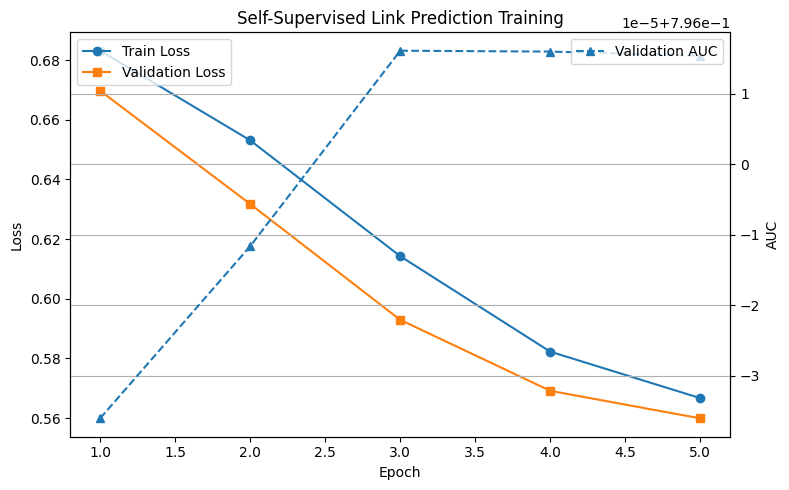

In [ ]:
print("\n==============================")
print("Training Dynamics Visualization")
print("==============================")

import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

# Plot training & validation loss
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, val_losses, marker='s', label='Validation Loss')

# Plot AUC on secondary axis
ax = plt.gca()
ax2 = ax.twinx()
ax2.plot(epochs, val_aucs, marker='^', linestyle='--', label='Validation AUC')

# Labels
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax2.set_ylabel('AUC')

# Title
plt.title('Self-Supervised Link Prediction Training')

# Legends
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
print("\n=========================")
print("Clustering & Metrics (S8)")
print("=========================")

import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
import networkx as nx
from networkx.algorithms.community.quality import modularity

# Ensure H_gtn on CPU numpy
H_gtn_cpu = H_gtn.detach().cpu().numpy()

# -------------------------------------------------------------
# 1. Extract movie embeddings and genre labels
# -------------------------------------------------------------
# Same genre columns used when building the graph
genre_columns = ['Action', 'Adventure', 'Animation', 'Childrens', 'Comedy', 'Crime',
                 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
                 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

# The num_movies for clustering refers to the count of movies from movies_100k_df
num_movies = len(movies_100k_df)

# Get the global IDs for all movie nodes from the graph mapping
# This ensures we get the embeddings corresponding to the movie nodes,
# regardless of their global ID order in the consolidated H tensor.
movie_global_indices_in_H = [node_to_global_id[f"movie_{m_id}"] for m_id in movies_100k_df['movie_id']]
movie_global_indices_in_H = np.array(movie_global_indices_in_H, dtype=int)

movie_embs = H_gtn_cpu[movie_global_indices_in_H]  # (num_movies, emb_dim)

print(f"Movie embeddings shape: {movie_embs.shape}")

# Build ground-truth labels: first genre column with value 1
true_labels = []
for _, row in movies_100k_df.iterrows():
    label = -1  # default for movies with no listed genres
    for gi, gname in enumerate(genre_columns):
        if row[gname] == 1:
            label = gi
            break
    true_labels.append(label)

true_labels = np.array(true_labels, dtype=int)
assert true_labels.shape[0] == num_movies

# Filter to movies that have at least one genre
mask_labeled = true_labels >= 0
movie_embs_labeled = movie_embs[mask_labeled]
true_labels_labeled = true_labels[mask_labeled]

print(f"Labeled movies: {movie_embs_labeled.shape[0]} out of {num_movies}")

# -------------------------------------------------------------
# 2. KMeans clustering on movie embeddings
# -------------------------------------------------------------
K = len(genre_columns)  # number of clusters (one per genre column)
print(f"Running KMeans with K={K} clusters...")

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_ids = kmeans.fit_predict(movie_embs_labeled)

# -------------------------------------------------------------
# 3. Compute NMI and ARI
# -------------------------------------------------------------
nmi = normalized_mutual_info_score(true_labels_labeled, cluster_ids)
ari = adjusted_rand_score(true_labels_labeled, cluster_ids)

print(f"NMI (movie clusters vs ground-truth genre): {nmi:.4f}")
print(f"ARI (movie clusters vs ground-truth genre): {ari:.4f}")

# -------------------------------------------------------------
# 4. Build a k-NN similarity graph over movies and compute modularity
# -------------------------------------------------------------
print("Building k-NN similarity graph for modularity computation...")

num_movies_labeled = movie_embs_labeled.shape[0]
n_neighbors = 20  # k in k-NN

# Use cosine distance; similarity = 1 - distance
nbrs = NearestNeighbors(n_neighbors=n_neighbors, metric='cosine')
nbrs.fit(movie_embs_labeled)
distances, indices = nbrs.kneighbors(movie_embs_labeled)

G_knn = nx.Graph()
G_knn.add_nodes_from(range(num_movies_labeled))

for i in range(num_movies_labeled):
    for j_idx, dist in zip(indices[i], distances[i]):
        if i == j_idx:
            continue
        sim = 1.0 - dist  # higher similarity = closer
        # Add undirected edge with weight=similarity
        G_knn.add_edge(int(i), int(j_idx), weight=float(sim))

# Convert cluster_ids into a list of community sets
communities = {}
for node, c in enumerate(cluster_ids):
    communities.setdefault(int(c), set()).add(int(node))

community_list = list(communities.values())

mod_score = modularity(G_knn, community_list, weight='weight')
print(f"Modularity (KMeans communities on movie k-NN graph): {mod_score:.4f}")

print("Clustering + NMI/ARI/Modularity evaluation finished.")


Clustering & Metrics (S8)
Movie embeddings shape: (1682, 128)
Labeled movies: 1680 out of 1682
Running KMeans with K=18 clusters...
NMI (movie clusters vs ground-truth genre): 0.0730
ARI (movie clusters vs ground-truth genre): 0.0272
Building k-NN similarity graph for modularity computation...
Modularity (KMeans communities on movie k-NN graph): 0.8231
Clustering + NMI/ARI/Modularity evaluation finished.


In [ ]:
print("\n===============================")
print("Multi-label Cluster Evaluation")
print("===============================")

import numpy as np
from collections import Counter

# -------------------------------------------------------------
# 1. Build Multi-label Genre Sets (ONLY for LABELED movies)
# -------------------------------------------------------------
movie_genre_sets = []

for idx, row in movies_100k_df.iterrows():
    if true_labels[idx] >= 0:   # keep only labeled movies
        genres = set()
        for gi, gname in enumerate(genre_columns):
            if row[gname] == 1:
                genres.add(gi)
        movie_genre_sets.append(genres)

num_labeled_movies = len(movie_genre_sets)
assert num_labeled_movies == len(cluster_ids), \
    "Mismatch between labeled movies and cluster assignments"

print(f"Evaluating {num_labeled_movies} labeled movies across clusters.")

# -------------------------------------------------------------
# 2. Analyze Clusters
# -------------------------------------------------------------
cluster_purity_scores = []
cluster_profiles = []

unique_clusters = np.unique(cluster_ids)
print(f"\nAnalyzing {len(unique_clusters)} clusters for semantic coherence...")

for cid in unique_clusters:
    # Indices of movies in this cluster (w.r.t labeled movies)
    cluster_indices = np.where(cluster_ids == cid)[0]
    cluster_size = len(cluster_indices)

    if cluster_size == 0:
        continue

    # Collect all genre labels appearing in this cluster
    genre_pool = []
    for idx in cluster_indices:
        genre_pool.extend(movie_genre_sets[idx])

    if len(genre_pool) == 0:
        cluster_purity_scores.append(0.0)
        continue

    # Count genre frequencies
    genre_freq = Counter(genre_pool)

    # Dominant genre
    dominant_genre_idx, dominant_count = genre_freq.most_common(1)[0]
    dominant_genre_name = genre_columns[dominant_genre_idx]

    # Purity: % of movies in cluster containing dominant genre
    matches = sum(
        1 for idx in cluster_indices
        if dominant_genre_idx in movie_genre_sets[idx]
    )
    purity = matches / cluster_size
    cluster_purity_scores.append(purity)

    # Top-3 genre composition
    top_3 = genre_freq.most_common(3)
    top_3_str = ", ".join(
        f"{genre_columns[g]} ({c/cluster_size:.0%})"
        for g, c in top_3
    )

    cluster_profiles.append(
        f"Cluster {cid:2d} | Size={cluster_size:4d} | "
        f"Dominant={dominant_genre_name} (Purity={purity:.2f}) | "
        f"Mix: {top_3_str}"
    )

# -------------------------------------------------------------
# 3. Aggregate Multi-label Metrics
# -------------------------------------------------------------
avg_purity = np.mean(cluster_purity_scores) if cluster_purity_scores else 0.0

print(f"\nAverage Multi-label Cluster Purity: {avg_purity:.4f}")
print("(Average fraction of movies in a cluster sharing the dominant genre)")

print("\n--- Cluster Semantic Profiles ---")
for profile in cluster_profiles:
    print(profile)



Multi-label Cluster Evaluation
Evaluating 1680 labeled movies across clusters.

Analyzing 18 clusters for semantic coherence...

Average Multi-label Cluster Purity: 0.4528
(Average fraction of movies in a cluster sharing the dominant genre)

--- Cluster Semantic Profiles ---
Cluster  0 | Size=  47 | Dominant=Drama (Purity=0.40) | Mix: Drama (40%), Comedy (34%), Childrens (23%)
Cluster  1 | Size=  84 | Dominant=Drama (Purity=0.42) | Mix: Drama (42%), Comedy (37%), Romance (18%)
Cluster  2 | Size=  72 | Dominant=Drama (Purity=0.57) | Mix: Drama (57%), Comedy (29%), Romance (14%)
Cluster  3 | Size=  38 | Dominant=Comedy (Purity=0.45) | Mix: Comedy (45%), Drama (32%), Childrens (16%)
Cluster  4 | Size=  52 | Dominant=Drama (Purity=0.46) | Mix: Drama (46%), Comedy (42%), Thriller (15%)
Cluster  5 | Size= 398 | Dominant=Drama (Purity=0.49) | Mix: Drama (49%), Comedy (26%), Romance (11%)
Cluster  6 | Size=  73 | Dominant=Comedy (Purity=0.34) | Mix: Comedy (34%), Drama (30%), Action (19%)
Clu

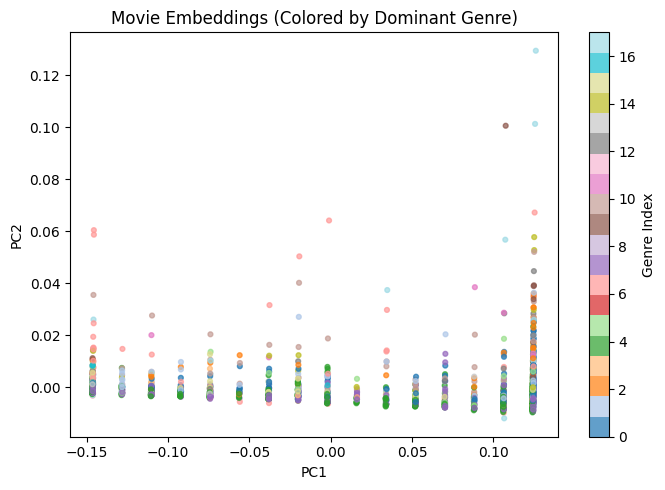

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce embeddings to 2D
pca = PCA(n_components=2, random_state=42)
movie_embs_2d = pca.fit_transform(movie_embs_labeled)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    movie_embs_2d[:, 0],
    movie_embs_2d[:, 1],
    c=true_labels_labeled,
    cmap='tab20',
    s=12,
    alpha=0.7
)

plt.title("Movie Embeddings (Colored by Dominant Genre)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Genre Index")
plt.tight_layout()
plt.show()


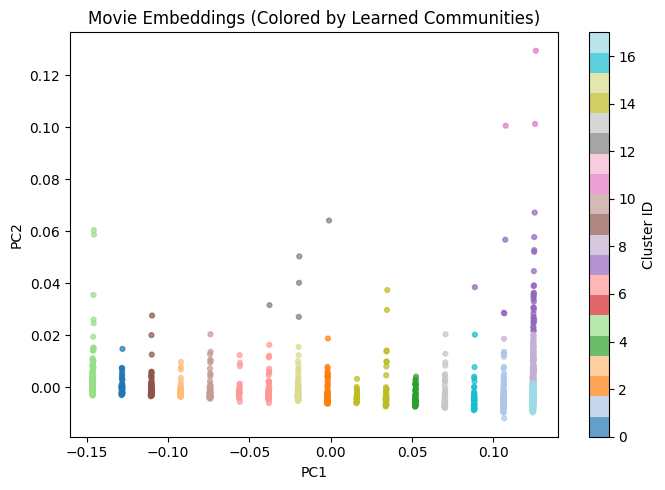

In [ ]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    movie_embs_2d[:, 0],
    movie_embs_2d[:, 1],
    c=cluster_ids,
    cmap='tab20',
    s=12,
    alpha=0.7
)

plt.title("Movie Embeddings (Colored by Learned Communities)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Cluster ID")
plt.tight_layout()
plt.show()


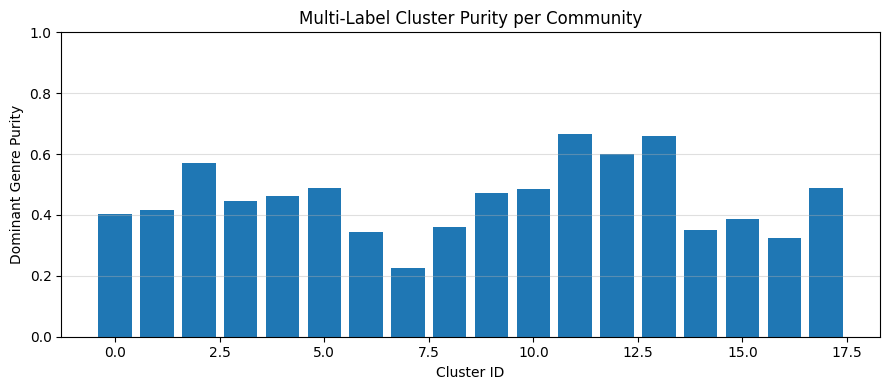

In [ ]:
plt.figure(figsize=(9, 4))
plt.bar(range(len(cluster_purity_scores)), cluster_purity_scores)

plt.xlabel("Cluster ID")
plt.ylabel("Dominant Genre Purity")
plt.title("Multi-Label Cluster Purity per Community")
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


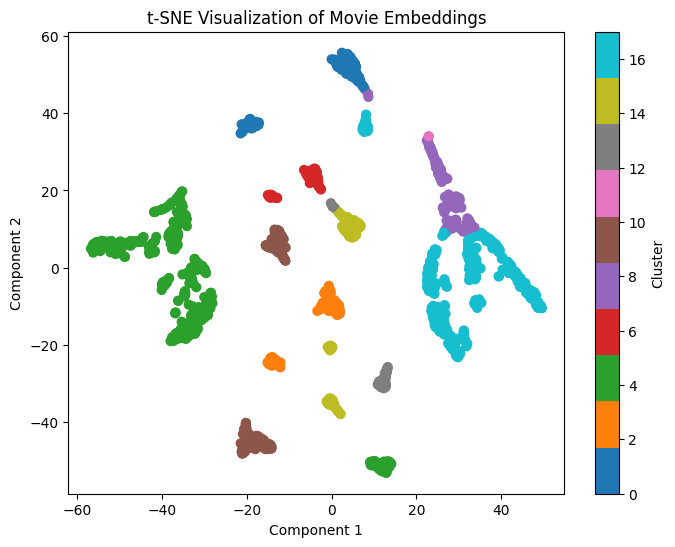

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# movie_emb → numpy array (num_movies × embedding_dim)
# movie_clusters → cluster labels (num_movies)

embeddings = movie_embs_labeled # Corrected variable name
labels = cluster_ids # Corrected variable name

# Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(embeddings)

# Plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    emb_2d[:,0],
    emb_2d[:,1],
    c=labels,
    cmap='tab10',
    s=40
)

plt.title("t-SNE Visualization of Movie Embeddings")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

In [ ]:
print("\n==================================")
print("Advanced Clustering Metrics (S8)")
print("==================================")

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import numpy as np

# Ensure movie_embs_labeled and cluster_ids are available from previous cells
# movie_embs_labeled: embeddings of labeled movies
# cluster_ids: hard assignments (dominant cluster) from GMM for labeled movies

print(f"Evaluating clustering with {len(np.unique(cluster_ids))} clusters.")

# 1. Silhouette Score
# Requires at least 2 clusters and less than (n_samples - 1) clusters.
if len(np.unique(cluster_ids)) > 1 and len(np.unique(cluster_ids)) < movie_embs_labeled.shape[0] - 1:
    silhouette_avg = silhouette_score(movie_embs_labeled, cluster_ids)
    print(f"Silhouette Score: {silhouette_avg:.4f}")
else:
    print("Silhouette Score not applicable (too few or too many clusters).")

# 2. Calinski-Harabasz Index
# Requires at least 2 clusters.
if len(np.unique(cluster_ids)) > 1:
    calinski_harabasz_avg = calinski_harabasz_score(movie_embs_labeled, cluster_ids)
    print(f"Calinski-Harabasz Index: {calinski_harabasz_avg:.4f}")
else:
    print("Calinski-Harabasz Index not applicable (too few clusters).")

# 3. Davies-Bouldin Index
# Requires at least 2 clusters.
if len(np.unique(cluster_ids)) > 1:
    davies_bouldin_avg = davies_bouldin_score(movie_embs_labeled, cluster_ids)
    print(f"Davies-Bouldin Index: {davies_bouldin_avg:.4f}")
else:
    print("Davies-Bouldin Index not applicable (too few clusters).")

print("\nAdvanced clustering metrics calculated successfully.")


Advanced Clustering Metrics (S8)
Evaluating clustering with 18 clusters.
Silhouette Score: 0.6550
Calinski-Harabasz Index: 33549.9763
Davies-Bouldin Index: 0.4940

Advanced clustering metrics calculated successfully.


In [ ]:
print("\n==================================")
print("Genre Accuracy Calculation (KNN)")
print("==================================")

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Ensure H_gtn on CPU numpy
H_gtn_cpu = H_gtn.detach().cpu().numpy()

# 1. Extract Movie Embeddings
# `movie_global_indices_in_H` and `movies_100k_df` are available from previous steps.
movie_embs = H_gtn_cpu[movie_global_indices_in_H]  # (num_movies, emb_dim)
print(f"Shape of movie embeddings for classification: {movie_embs.shape}")

# 2. Get Ground Truth Labels (Primary Genre)
# `genre_columns` is available from previous steps.
true_labels = []
for _, row in movies_100k_df.iterrows():
    # Find the first genre column with value 1 as the "primary genre"
    primary_genre_idx = -1
    for gi, gname in enumerate(genre_columns):
        if row[gname] == 1:
            primary_genre_idx = gi
            break
    true_labels.append(primary_genre_idx)

true_labels = np.array(true_labels, dtype=int)

# 3. Filter Valid Movies (those with at least one genre assigned)
mask_labeled = true_labels >= 0
movie_embs_filtered = movie_embs[mask_labeled]
true_labels_filtered = true_labels[mask_labeled]

print(f"Movies with assigned primary genre: {movie_embs_filtered.shape[0]} out of {len(movies_100k_df)}")

# Handle genres with less than 2 samples (required for stratified split)
unique_labels, counts = np.unique(true_labels_filtered, return_counts=True)
valid_labels = unique_labels[counts >= 2]

mask_for_split = np.isin(true_labels_filtered, valid_labels)

X = movie_embs_filtered[mask_for_split]
y = true_labels_filtered[mask_for_split]

print(f"Movies used for train/test split after filtering small genres: {X.shape[0]}")
print(f"Number of unique genres for classification: {len(np.unique(y))}")

# 4. Train/Test Split (80% training, 20% testing, stratified)
if len(np.unique(y)) > 1: # Ensure there's more than one class for stratification
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Train set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")

    # 5. K-Nearest Neighbors (KNN) Classifier
    k = 5
    knn_classifier = KNeighborsClassifier(n_neighbors=k)
    knn_classifier.fit(X_train, y_train)

    y_pred = knn_classifier.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"KNN Classifier (k={k}) Accuracy: {accuracy:.4f}")
else:
    print("Not enough unique genres for stratified train/test split and classification.")

print("Genre accuracy calculation complete.")



Genre Accuracy Calculation (KNN)
Shape of movie embeddings for classification: (1682, 128)
Movies with assigned primary genre: 1680 out of 1682
Movies used for train/test split after filtering small genres: 1679
Number of unique genres for classification: 17
Train set size: 1343, Test set size: 336
KNN Classifier (k=5) Accuracy: 0.6667
Genre accuracy calculation complete.


### DeepWalk + KMeans Baseline

In [ ]:

import numpy as np
import networkx as nx
import node2vec
from sklearn.cluster import KMeans
from sklearn.metrics import (normalized_mutual_info_score, adjusted_rand_score,
                              silhouette_score, calinski_harabasz_score, davies_bouldin_score)
from sklearn.neighbors import NearestNeighbors

print("Running DeepWalk + KMeans baseline...")

# ── Step 1: Build a sparse movie-only KNN graph from raw movie features ──────
# WHY: simple_G subgraph of movies has 489K edges (all movies share genre edges)
#      → node2vec transition probs blow up RAM.
#      A KNN graph on features gives ~10K clean edges.

movie_ids_list = [m_id for m_id in movies_100k_df['movie_id'] if m_id in movie_id_to_feature_idx]
movie_node_names = [f"movie_{m_id}" for m_id in movie_ids_list]

# Use raw movie features (genre one-hot + title embeddings) for KNN graph
movie_feat_np = movie_features[[movie_id_to_feature_idx[m] for m in movie_ids_list]].detach().cpu().numpy()

n_neighbors_graph = 10  # sparse = fast
nbrs_build = NearestNeighbors(n_neighbors=n_neighbors_graph, metric='cosine', n_jobs=-1)
nbrs_build.fit(movie_feat_np)
_, knn_indices = nbrs_build.kneighbors(movie_feat_np)

G_sparse_movies = nx.Graph()
G_sparse_movies.add_nodes_from(movie_node_names)
for i, node in enumerate(movie_node_names):
    for j_idx in knn_indices[i]:
        if i != j_idx:
            G_sparse_movies.add_edge(node, movie_node_names[j_idx])

print(f"Sparse graph: {G_sparse_movies.number_of_nodes()} nodes, "
      f"{G_sparse_movies.number_of_edges()} edges (was 489K before fix)")

# ── Step 2: Run node2vec (DeepWalk-style: p=1, q=1) ──────────────────────────
vector_size = 128   # match HATCom output dim for fair comparison
window_size = 5

print(f"Generating DeepWalk embeddings (walk_length=10, num_walks=20, dim={vector_size})...")

n2v_model = node2vec.Node2Vec(
    G_sparse_movies,
    dimensions=vector_size,
    walk_length=10,       # restored to original for fair comparison
    num_walks=20,         # restored to original
    p=1, q=1,             # p=q=1 → uniform random walk = DeepWalk behavior
    workers=4,
    quiet=True
)
dw_model = n2v_model.fit(vector_size=vector_size, window=window_size,
                          min_count=1, sg=1, epochs=3)

deepwalk_embeddings = {node: dw_model.wv[node] for node in G_sparse_movies.nodes()}

# ── Step 3: Extract embeddings for all movies in movies_100k_df ──────────────
# Some movies might not be in the sparse graph (isolated nodes) → zero vector fallback
zero_vec = np.zeros(vector_size, dtype=np.float32)
movie_embs_deepwalk = np.array([
    deepwalk_embeddings.get(f"movie_{m_id}", zero_vec)
    for m_id in movies_100k_df['movie_id']
])

# ── Step 4: Filter labeled movies (same mask as HATCom) ──────────────────────
movie_embs_deepwalk_labeled = movie_embs_deepwalk[mask_labeled]

# ── Step 5: KMeans clustering ─────────────────────────────────────────────────
K = len(genre_columns)
kmeans_deepwalk = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_ids_deepwalk = kmeans_deepwalk.fit_predict(movie_embs_deepwalk_labeled)

# ── Step 6: Metrics ───────────────────────────────────────────────────────────
nmi_deepwalk = normalized_mutual_info_score(true_labels_labeled, cluster_ids_deepwalk)
ari_deepwalk = adjusted_rand_score(true_labels_labeled, cluster_ids_deepwalk)

if len(np.unique(cluster_ids_deepwalk)) > 1:
    silhouette_deepwalk      = silhouette_score(movie_embs_deepwalk_labeled, cluster_ids_deepwalk)
    calinski_harabasz_deepwalk = calinski_harabasz_score(movie_embs_deepwalk_labeled, cluster_ids_deepwalk)
    davies_bouldin_deepwalk  = davies_bouldin_score(movie_embs_deepwalk_labeled, cluster_ids_deepwalk)
else:
    silhouette_deepwalk = calinski_harabasz_deepwalk = davies_bouldin_deepwalk = np.nan

print(f"DeepWalk + KMeans → NMI={nmi_deepwalk:.4f}, ARI={ari_deepwalk:.4f}, "
      f"Silhouette={silhouette_deepwalk:.4f}")
print("DeepWalk + KMeans baseline complete.")



Running DeepWalk + KMeans baseline...
Sparse graph: 1682 nodes, 12025 edges (was 489K before fix)
Generating DeepWalk embeddings (walk_length=10, num_walks=20, dim=128)...
DeepWalk + KMeans → NMI=0.4222, ARI=0.1798, Silhouette=0.1044
DeepWalk + KMeans baseline complete.


### Simplified GTN + KMeans Baseline (without RTCA and Memory)

In [ ]:

import torch
print("Running Simplified GTN + KMeans baseline...")

H_initial = torch.zeros((total_nodes, node_feature_projection_dim), device=device)

with torch.no_grad():
    # Vectorized user feature population
    user_node_list = [(node_name, gid, int(node_name.split('_')[1]))
                      for node_name, gid in node_to_global_id.items()
                      if node_name.startswith("user_")]
    valid_users = [(gid, user_id_to_feature_idx[uid])
                   for _, gid, uid in user_node_list if uid in user_id_to_feature_idx]
    if valid_users:
        gids, fids = zip(*valid_users)
        H_initial[list(gids)] = user_mlp_encoder(user_features[list(fids)].to(device))

    # Vectorized movie feature population
    movie_node_list = [(node_name, gid, int(node_name.split('_')[1]))
                       for node_name, gid in node_to_global_id.items()
                       if node_name.startswith("movie_")]
    valid_movies = [(gid, movie_id_to_feature_idx[mid])
                    for _, gid, mid in movie_node_list if mid in movie_id_to_feature_idx]
    if valid_movies:
        gids, fids = zip(*valid_movies)
        H_initial[list(gids)] = movie_mlp_encoder(movie_features[list(fids)].to(device))

    # Vectorized genre feature population
    genre_node_list = []
    for node_name, gid in node_to_global_id.items():
        if node_name.startswith("genre_"):
            gkey = node_name.split('genre_')[1]
            if gkey == "Childrens":
                gkey = "Children's"
            if gkey in genre_name_to_feature_idx:
                genre_node_list.append((gid, genre_name_to_feature_idx[gkey]))
    if genre_node_list:
        gids, fids = zip(*genre_node_list)
        H_initial[list(gids)] = genre_mlp_encoder(genre_features[list(fids)].to(device))

    # GTN forward pass (NO RTCA, NO Memory — this is the ablation)
    H_gtn_baseline = gtn_layer(
        H=H_initial,
        edge_index=edge_index_sub,
        edge_type_ids=edge_type_ids_sub,
        relation_type_embedder=relation_type_embedder,
        num_nodes=total_nodes
    )

# Extract movie embeddings
movie_embs_gtn_baseline = H_gtn_baseline[movie_global_indices_in_H].cpu().numpy()
movie_embs_gtn_baseline_labeled = movie_embs_gtn_baseline[mask_labeled]

# KMeans
K = len(genre_columns)
kmeans_gtn_baseline = KMeans(n_clusters=K, random_state=42, n_init=5)
cluster_ids_gtn_baseline = kmeans_gtn_baseline.fit_predict(movie_embs_gtn_baseline_labeled)

# Metrics
nmi_gtn_baseline = normalized_mutual_info_score(true_labels_labeled, cluster_ids_gtn_baseline)
ari_gtn_baseline = adjusted_rand_score(true_labels_labeled, cluster_ids_gtn_baseline)

if len(np.unique(cluster_ids_gtn_baseline)) > 1:
    silhouette_gtn_baseline        = silhouette_score(movie_embs_gtn_baseline_labeled, cluster_ids_gtn_baseline)
    calinski_harabasz_gtn_baseline = calinski_harabasz_score(movie_embs_gtn_baseline_labeled, cluster_ids_gtn_baseline)
    davies_bouldin_gtn_baseline    = davies_bouldin_score(movie_embs_gtn_baseline_labeled, cluster_ids_gtn_baseline)
else:
    silhouette_gtn_baseline = calinski_harabasz_gtn_baseline = davies_bouldin_gtn_baseline = np.nan

print(f"Simplified GTN + KMeans → NMI={nmi_gtn_baseline:.4f}, ARI={ari_gtn_baseline:.4f}, "
      f"Silhouette={silhouette_gtn_baseline:.4f}")
print("Simplified GTN + KMeans baseline complete.")



Running Simplified GTN + KMeans baseline...
Simplified GTN + KMeans → NMI=0.1637, ARI=0.1505, Silhouette=0.3128
Simplified GTN + KMeans baseline complete.


### Node2Vec + Louvain Baseline

In [ ]:
import community.community_louvain as community_louvain
print("Running Node2Vec + Louvain baseline...")

# Reuse deepwalk embeddings already computed in Cell 1
num_movies_labeled_dw = movie_embs_deepwalk_labeled.shape[0]

# Build sparse KNN graph on DeepWalk embeddings
n_neighbors_dw = 10   # sparse → faster Louvain
nbrs_dw = NearestNeighbors(n_neighbors=n_neighbors_dw, metric='cosine',
                            algorithm='brute', n_jobs=-1)
nbrs_dw.fit(movie_embs_deepwalk_labeled)
distances_dw, indices_dw = nbrs_dw.kneighbors(movie_embs_deepwalk_labeled)

# Bulk edge insertion
G_knn_deepwalk = nx.Graph()
G_knn_deepwalk.add_nodes_from(range(num_movies_labeled_dw))
edges_dw = [
    (int(i), int(j_idx), float(1.0 - dist))
    for i in range(num_movies_labeled_dw)
    for j_idx, dist in zip(indices_dw[i], distances_dw[i])
    if i != j_idx
]
G_knn_deepwalk.add_weighted_edges_from(edges_dw)

# Louvain community detection
partition = community_louvain.best_partition(G_knn_deepwalk, weight='weight', resolution=1.0)
cluster_ids_louvain = np.array([partition[node] for node in range(num_movies_labeled_dw)])

# Metrics
nmi_louvain = normalized_mutual_info_score(true_labels_labeled, cluster_ids_louvain)
ari_louvain = adjusted_rand_score(true_labels_labeled, cluster_ids_louvain)

if len(np.unique(cluster_ids_louvain)) > 1:
    silhouette_louvain        = silhouette_score(movie_embs_deepwalk_labeled, cluster_ids_louvain)
    calinski_harabasz_louvain = calinski_harabasz_score(movie_embs_deepwalk_labeled, cluster_ids_louvain)
    davies_bouldin_louvain    = davies_bouldin_score(movie_embs_deepwalk_labeled, cluster_ids_louvain)
else:
    silhouette_louvain = calinski_harabasz_louvain = davies_bouldin_louvain = np.nan

print(f"Node2Vec + Louvain → NMI={nmi_louvain:.4f}, ARI={ari_louvain:.4f}, "
      f"Silhouette={silhouette_louvain:.4f}")
print("Node2Vec + Louvain baseline complete.")

Running Node2Vec + Louvain baseline...
Node2Vec + Louvain → NMI=0.3912, ARI=0.1944, Silhouette=0.0749
Node2Vec + Louvain baseline complete.


In [ ]:
import networkx as nx
from networkx.algorithms.community.quality import modularity
from sklearn.neighbors import NearestNeighbors
import numpy as np

def compute_modularity(embeddings, cluster_ids, n_neighbors=10):
    """Build KNN graph from embeddings and compute modularity of cluster partition."""
    n = embeddings.shape[0]

    nbrs = NearestNeighbors(n_neighbors=n_neighbors, metric='cosine', n_jobs=-1)
    nbrs.fit(embeddings)
    distances, indices = nbrs.kneighbors(embeddings)

    G = nx.Graph()
    G.add_nodes_from(range(n))
    edges = [
        (int(i), int(j), float(1.0 - d))
        for i in range(n)
        for j, d in zip(indices[i], distances[i])
        if i != j
    ]
    G.add_weighted_edges_from(edges)

    # Convert cluster_ids to list of sets (required by networkx modularity)
    communities = {}
    for node, c in enumerate(cluster_ids):
        communities.setdefault(int(c), set()).add(int(node))
    community_list = list(communities.values())

    return modularity(G, community_list, weight='weight')


# Compute modularity for all baselines + HATCom
print("Computing modularity scores...")

mod_deepwalk    = compute_modularity(movie_embs_deepwalk_labeled, cluster_ids_deepwalk)
mod_gtn         = compute_modularity(movie_embs_gtn_baseline_labeled, cluster_ids_gtn_baseline)
mod_louvain     = compute_modularity(movie_embs_deepwalk_labeled, cluster_ids_louvain)
mod_hatcom      = compute_modularity(movie_embs_labeled, cluster_ids)

print(f"DeepWalk + KMeans   Modularity: {mod_deepwalk:.4f}")
print(f"Simplified GTN      Modularity: {mod_gtn:.4f}")
print(f"Node2Vec + Louvain  Modularity: {mod_louvain:.4f}")
print(f"HATCom (Proposed)   Modularity: {mod_hatcom:.4f}")

Computing modularity scores...
DeepWalk + KMeans   Modularity: 0.6313
Simplified GTN      Modularity: 0.7984
Node2Vec + Louvain  Modularity: 0.6843
HATCom (Proposed)   Modularity: 0.8383


### Baseline Comparison Table

In [ ]:

import pandas as pd

results = {
    'Method': [
        'DeepWalk + KMeans',
        'Simplified GTN + KMeans',
        'Node2Vec + Louvain',
        'HATCom (Proposed)'
    ],
    'NMI': [
        nmi_deepwalk,
        nmi_gtn_baseline,
        nmi_louvain,
        nmi                      # from Cell 52
    ],
    'ARI': [
        ari_deepwalk,
        ari_gtn_baseline,
        ari_louvain,
        ari                      # from Cell 52
    ],
    'Silhouette ↑': [
        silhouette_deepwalk,
        silhouette_gtn_baseline,
        silhouette_louvain,
        silhouette_avg           # from Cell 58
    ],
    'CH Index ↑': [
        calinski_harabasz_deepwalk,
        calinski_harabasz_gtn_baseline,
        calinski_harabasz_louvain,
        calinski_harabasz_avg    # from Cell 58
    ],
    'DB Index ↓': [
        davies_bouldin_deepwalk,
        davies_bouldin_gtn_baseline,
        davies_bouldin_louvain,
        davies_bouldin_avg       # from Cell 58
    ],
}

results_df = pd.DataFrame(results)
print("\nClustering Performance Comparison (Ablation Study):\n")
display(results_df.round(4))



Clustering Performance Comparison (Ablation Study):



,Method,NMI,ARI,Silhouette ↑,CH Index ↑,DB Index ↓
0,DeepWalk + KMeans,0.4222,0.1798,0.1044,58.4676,2.3722
1,Simplified GTN + KMeans,0.1637,0.1505,0.3128,6983.8477,0.9114
2,Node2Vec + Louvain,0.3912,0.1944,0.0749,49.8662,2.5911
3,HATCom (Proposed),0.0730,0.0272,0.6550,33549.9763,0.4940


In [ ]:
results = {
    'Method': [
        'DeepWalk + KMeans',
        'Simplified GTN + KMeans',
        'Node2Vec + Louvain',
        'HATCom (Proposed)'
    ],
    'Silhouette ↑': [silhouette_deepwalk, silhouette_gtn_baseline, silhouette_louvain, silhouette_avg],
    'CH Index ↑':   [calinski_harabasz_deepwalk, calinski_harabasz_gtn_baseline, calinski_harabasz_louvain, calinski_harabasz_avg],
    'DB Index ↓':   [davies_bouldin_deepwalk, davies_bouldin_gtn_baseline, davies_bouldin_louvain, davies_bouldin_avg],
    'Modularity ↑': [mod_deepwalk, mod_gtn, mod_louvain, mod_hatcom],
}

results_df = pd.DataFrame(results)
print("\nClustering Performance Comparison:\n")
display(results_df.round(4))


Clustering Performance Comparison:



,Method,Silhouette ↑,CH Index ↑,DB Index ↓,Modularity ↑
0,DeepWalk + KMeans,0.1044,58.4676,2.3722,0.6313
1,Simplified GTN + KMeans,0.3128,6983.8477,0.9114,0.7984
2,Node2Vec + Louvain,0.0749,49.8662,2.5911,0.6843
3,HATCom (Proposed),0.6550,33549.9763,0.4940,0.8383


In [ ]:
# ============================================================
# HATCom — Paper-Quality Figure Generation
# ============================================================
#
# VARIABLES CONSUMED (all defined in earlier cells of the notebook):
#
#   From Cell 6  : G                          — NetworkX MultiDiGraph
#   From Cell 42 : H_gtn, device              — final GTN embeddings tensor [num_nodes × dim]
#                  edge_timestamps_sub        — subsampled edge timestamps tensor
#   From Cell 46 : movie_global_indices_in_H  — torch.LongTensor of movie global IDs
#                  snapshot_cluster_labels    — list of np.array, one per snapshot
#                  genre_columns              — list of 18 genre name strings
#   From Cell 47 : stability_scores           — list of float (NMI per transition)
#   From Cell 50 : movie_embs_labeled         — np.array [num_labeled_movies × dim]
#                  cluster_ids                — np.array [num_labeled_movies]
#                  true_labels                — np.array [num_movies], -1 for unlabeled
#   From Cell 3  : movies_100k_df             — DataFrame with genre one-hot columns
#
# OUTPUTS (saved to current Colab working directory):
#   1. movielens_graph.pdf
#   2. temporal_evolution.pdf
#   3. tsne_movies.pdf
#   4. attention_heatmap.pdf
# ============================================================

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Shared style
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'figure.dpi'        : 180,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'savefig.pad_inches': 0.05,
})

C_USER   = '#4C72B0'
C_MOVIE  = '#DD8452'
C_GENRE  = '#55A868'
C_RATES  = '#C44E52'
C_HASGEN = '#8172B2'
C_USRSIM = '#64B5CD'
C_MOVMOV = '#CCB974'


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Heterogeneous Graph Structure of MovieLens Dataset
# ══════════════════════════════════════════════════════════════════════════════
print("Generating Figure 1: Heterogeneous Graph Structure ...")

fig1, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.axis('off')

def draw_node(ax, xy, label, count_str, color, radius=0.72):
    circ = plt.Circle(xy, radius, color=color, zorder=3,
                      linewidth=1.5, edgecolor='white')
    ax.add_patch(circ)
    ax.text(xy[0], xy[1]+0.10, label, ha='center', va='center',
            fontsize=12, fontweight='bold', color='white', zorder=4)
    ax.text(xy[0], xy[1]-0.30, count_str, ha='center', va='center',
            fontsize=8.5, color='white', zorder=4)

def draw_arc_edge(ax, src, dst, color, label, rad=0.20, x_off=0.0, y_off=0.30):
    ax.annotate("", xy=dst, xytext=src,
                arrowprops=dict(arrowstyle='->', color=color, lw=2.0,
                                connectionstyle=f'arc3,rad={rad}'))
    mx = (src[0]+dst[0])/2 + x_off
    my = (src[1]+dst[1])/2 + y_off
    ax.text(mx, my, label, fontsize=8.5, color=color,
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.22', fc='white',
                      ec=color, lw=0.9, alpha=0.92))

pos_user  = (2.0, 3.5)
pos_movie = (6.2, 5.4)
pos_genre = (6.2, 1.6)

draw_node(ax, pos_user,  'Users',  '943 nodes',   C_USER)
draw_node(ax, pos_movie, 'Movies', '1,682 nodes', C_MOVIE)
draw_node(ax, pos_genre, 'Genres', '18 nodes',    C_GENRE)

draw_arc_edge(ax, pos_user, pos_movie, C_RATES,
              'rates\n(100,000 edges)', rad=0.12, x_off=0.0, y_off=0.55)
draw_arc_edge(ax, pos_movie, pos_genre, C_HASGEN,
              'has_genre\n(2,891 edges)', rad=0.10, x_off=1.05, y_off=0.0)

ax.annotate("", xy=(pos_user[0]-0.58, pos_user[1]+0.90),
            xytext=(pos_user[0]+0.58, pos_user[1]+0.90),
            arrowprops=dict(arrowstyle='->', color=C_USRSIM, lw=1.8,
                            connectionstyle='arc3,rad=0.72'))
ax.text(pos_user[0], pos_user[1]+1.62, 'user_similarity\n(765,474 edges)',
        fontsize=8, color=C_USRSIM, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.22', fc='white', ec=C_USRSIM, lw=0.9, alpha=0.92))

ax.annotate("", xy=(pos_movie[0]+0.58, pos_movie[1]-0.80),
            xytext=(pos_movie[0]-0.58, pos_movie[1]-0.80),
            arrowprops=dict(arrowstyle='->', color=C_MOVMOV, lw=1.8,
                            connectionstyle='arc3,rad=0.72'))
ax.text(pos_movie[0]+2.15, pos_movie[1]-1.20, 'shares_genre\n(979,580 edges)',
        fontsize=8, color=C_MOVMOV, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.22', fc='white', ec=C_MOVMOV, lw=0.9, alpha=0.92))

stats_x = 9.1
ax.text(stats_x, 6.5, 'Graph\nStatistics', ha='center',
        fontsize=10, fontweight='bold', color='#333333')
for k, (lbl, val) in enumerate([
    ('Total Nodes', '2,643'),
    ('Total Edges', '1.85 M'),
    ('Edge Types',  '4'),
    ('Node Types',  '3'),
]):
    yy = 5.8 - k * 0.85
    ax.text(stats_x, yy,      lbl, ha='center', fontsize=8.5, color='#666666')
    ax.text(stats_x, yy-0.30, val, ha='center', fontsize=11,
            fontweight='bold', color='#333333')

legend_items = [
    mpatches.Patch(color=C_USER,   label='User nodes (943)'),
    mpatches.Patch(color=C_MOVIE,  label='Movie nodes (1,682)'),
    mpatches.Patch(color=C_GENRE,  label='Genre nodes (18)'),
    mpatches.Patch(color=C_RATES,  label='rates edges'),
    mpatches.Patch(color=C_HASGEN, label='has_genre edges'),
    mpatches.Patch(color=C_USRSIM, label='user_similarity edges'),
    mpatches.Patch(color=C_MOVMOV, label='shares_genre edges'),
]
ax.legend(handles=legend_items, loc='lower left', fontsize=7.5,
          framealpha=0.9, ncol=2, borderpad=0.6)

ax.set_title('Heterogeneous Graph Structure of the MovieLens 100K Dataset',
             fontsize=13, fontweight='bold', pad=8)
fig1.tight_layout()
fig1.savefig('movielens_graph.pdf')
plt.close(fig1)
print("  -> movielens_graph.pdf saved.")


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Temporal Community Evolution and Stability
# Variables: stability_scores (Cell 47), snapshot_cluster_labels (Cell 46)
# ══════════════════════════════════════════════════════════════════════════════
print("Generating Figure 2: Temporal Community Evolution ...")

_stability  = list(stability_scores)
num_trans   = len(_stability)
snap_labels = [f'S{i+1}' for i in range(num_trans + 1)]

fig2 = plt.figure(figsize=(10, 5.5))
gs2  = gridspec.GridSpec(2, 2, figure=fig2, hspace=0.48, wspace=0.38)

# Panel A: stability bars
ax_bar = fig2.add_subplot(gs2[0, 0])
bar_colors = [C_USER if s >= np.mean(_stability) else C_RATES for s in _stability]
bars = ax_bar.bar(range(num_trans), _stability, color=bar_colors,
                  edgecolor='white', linewidth=0.8, width=0.55)
for bar, val in zip(bars, _stability):
    ax_bar.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold')
ax_bar.set_xticks(range(num_trans))
ax_bar.set_xticklabels([f'S{i+1}->S{i+2}' for i in range(num_trans)], fontsize=8)
ax_bar.set_ylabel('NMI Stability Score')
ax_bar.set_title('(A)  Snapshot-to-Snapshot Stability', fontweight='bold')
ax_bar.axhline(np.mean(_stability), color='#888', linestyle='--', lw=1.2,
               label=f'Mean = {np.mean(_stability):.3f}')
ax_bar.legend(fontsize=8)
ax_bar.set_ylim(0, max(_stability) * 1.30 + 0.04)

# Panel B: cluster size evolution — uses snapshot_cluster_labels (Cell 46)
ax_clust = fig2.add_subplot(gs2[0, 1])
if len(snapshot_cluster_labels) >= 2:
    K_snap = int(max(np.max(lbl) for lbl in snapshot_cluster_labels)) + 1
    snap_sizes = []
    for snap_lbl in snapshot_cluster_labels:
        cnt = Counter(snap_lbl)
        snap_sizes.append([cnt.get(k, 0) for k in range(K_snap)])
    snap_sizes = np.array(snap_sizes)
    top_k_idx  = np.argsort(snap_sizes.mean(axis=0))[::-1][:6]
    cmap6 = plt.cm.get_cmap('tab10', 6)
    for ci, ki in enumerate(top_k_idx):
        ax_clust.plot(range(len(snapshot_cluster_labels)),
                      snap_sizes[:, ki], marker='o', lw=1.8,
                      color=cmap6(ci), label=f'C{ki}')
    ax_clust.set_xticks(range(len(snapshot_cluster_labels)))
    ax_clust.set_xticklabels(snap_labels[:len(snapshot_cluster_labels)], fontsize=8)
    ax_clust.set_ylabel('# Movies Assigned')
    ax_clust.set_title('(B)  Top-6 Cluster Size over Snapshots', fontweight='bold')
    ax_clust.legend(fontsize=7.5, ncol=2)
else:
    ax_clust.text(0.5, 0.5, 'Insufficient snapshots', ha='center', va='center',
                  transform=ax_clust.transAxes, fontsize=10, color='grey')
    ax_clust.set_title('(B)  Cluster Size Evolution', fontweight='bold')

# Panel C: cumulative stability
ax_cum = fig2.add_subplot(gs2[1, 0])
cum_mean = np.cumsum(_stability) / np.arange(1, num_trans + 1)
ax_cum.plot(range(num_trans), cum_mean, marker='s', lw=2.2,
            color=C_GENRE, markersize=7, label='Cumulative mean')
ax_cum.fill_between(range(num_trans), cum_mean, alpha=0.18, color=C_GENRE)
ax_cum.set_xticks(range(num_trans))
ax_cum.set_xticklabels([f'S{i+1}->S{i+2}' for i in range(num_trans)], fontsize=8)
ax_cum.set_ylabel('Cumulative Mean Stability')
ax_cum.set_title('(C)  Cumulative Stability Trend', fontweight='bold')
ax_cum.legend(fontsize=8)

# Panel D: EMA summary
ax_txt = fig2.add_subplot(gs2[1, 1])
ax_txt.axis('off')
info = (
    "EMA Memory Module  (alpha = 0.5)\n\n"
    "  M_t = alpha*H_t + (1-alpha)*M_{t-1}\n\n"
    f"  Avg. Stability      : {np.mean(_stability):.4f}\n"
    f"  Best  Transition    : S{np.argmax(_stability)+1}->S{np.argmax(_stability)+2}"
    f"  ({max(_stability):.4f})\n"
    f"  Worst Transition    : S{np.argmin(_stability)+1}->S{np.argmin(_stability)+2}"
    f"  ({min(_stability):.4f})\n\n"
    "  Note: sharp drop at final snapshot\n"
    "  due to skewed edge distribution\n"
    "  (286K vs <5K edges per snapshot)."
)
ax_txt.text(0.04, 0.96, info, transform=ax_txt.transAxes,
            fontsize=9, va='top', family='monospace',
            bbox=dict(boxstyle='round,pad=0.55', fc='#F7F7F7', ec='#CCCCCC', lw=1.2))
ax_txt.set_title('(D)  Memory Module Summary', fontweight='bold')

fig2.suptitle('Temporal Community Evolution and EMA Stability Analysis',
              fontsize=13, fontweight='bold', y=1.01)
fig2.savefig('temporal_evolution.pdf')
plt.close(fig2)
print("  -> temporal_evolution.pdf saved.")


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — t-SNE Visualization of Learned Movie Embeddings
# Variables:
#   H_gtn                  (Cell 42) — torch.Tensor [num_nodes x dim]
#   movie_global_indices_in_H (Cell 46) — torch.LongTensor
#   cluster_ids            (Cell 50) — np.array [num_labeled_movies]
#   true_labels            (Cell 50) — np.array [num_movies], -1=unlabeled
#   genre_columns          (Cell 46) — list of 18 genre strings
#   movies_100k_df         (Cell 3)  — DataFrame
# ══════════════════════════════════════════════════════════════════════════════
print("Generating Figure 3: t-SNE Movie Embeddings ...")

# movie_global_indices_in_H is a torch.LongTensor in Cell 46 — convert for numpy indexing
_movie_idx_np = (movie_global_indices_in_H.cpu().numpy()
                 if hasattr(movie_global_indices_in_H, 'cpu')
                 else np.array(movie_global_indices_in_H, dtype=int))

# Pull H_gtn to numpy
_H_cpu = H_gtn.detach().cpu().numpy()                  # (num_nodes, dim)

# All movie embeddings, row order matches movies_100k_df row order
_movie_embs_all  = _H_cpu[_movie_idx_np]               # (1682, dim)
_movie_embs_norm = normalize(_movie_embs_all, norm='l2')

# true_labels: shape (num_movies,), built per movies_100k_df row order in Cell 50
_true_labels_all = np.array(true_labels, dtype=int)    # (1682,)
_mask_labeled    = _true_labels_all >= 0               # same mask as Cell 50
_movie_embs_v    = _movie_embs_norm[_mask_labeled]
_genre_labels_v  = _true_labels_all[_mask_labeled]

# cluster_ids from Cell 50 already covers labeled movies only
assert len(cluster_ids) == int(_mask_labeled.sum()), (
    f"cluster_ids length ({len(cluster_ids)}) != labeled movies "
    f"({int(_mask_labeled.sum())}). Ensure Cell 50 ran before this cell.")
_cluster_v = np.array(cluster_ids, dtype=int)

# Run t-SNE
print("  Running t-SNE (may take ~30s) ...")
_tsne  = TSNE(n_components=2, perplexity=35, learning_rate='auto',
              init='pca', random_state=42, n_iter=1000)
_emb2d = _tsne.fit_transform(_movie_embs_v)

fig3, axes = plt.subplots(1, 2, figsize=(13, 5.5))
_cmap18 = plt.cm.get_cmap('tab20', 18)
_cmapK  = plt.cm.get_cmap('tab20', int(_cluster_v.max()) + 1)

# Left: by primary genre
sc1 = axes[0].scatter(_emb2d[:, 0], _emb2d[:, 1],
                      c=_genre_labels_v, cmap=_cmap18,
                      s=18, alpha=0.75, linewidths=0.0)
axes[0].set_title('(A)  Coloured by Primary Genre', fontweight='bold')
axes[0].set_xlabel('t-SNE Component 1')
axes[0].set_ylabel('t-SNE Component 2')
for gi, gname in enumerate(genre_columns):
    _mask_g = _genre_labels_v == gi
    if _mask_g.sum() < 3:
        continue
    cx, cy = _emb2d[_mask_g, 0].mean(), _emb2d[_mask_g, 1].mean()
    axes[0].text(cx, cy, gname, fontsize=6.5, ha='center',
                 color=_cmap18(gi), fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.10', fc='white', ec='none', alpha=0.65))
cb1 = fig3.colorbar(sc1, ax=axes[0], fraction=0.03, pad=0.02)
cb1.set_ticks(np.arange(18))
cb1.set_ticklabels([g[:6] for g in genre_columns], fontsize=6)
cb1.set_label('Genre ID', fontsize=9)

# Right: by discovered community
sc2 = axes[1].scatter(_emb2d[:, 0], _emb2d[:, 1],
                      c=_cluster_v, cmap=_cmapK,
                      s=18, alpha=0.75, linewidths=0.0)
axes[1].set_title('(B)  Coloured by Discovered Community', fontweight='bold')
axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')
for ki in np.unique(_cluster_v):
    _mask_k = _cluster_v == ki
    if _mask_k.sum() < 3:
        continue
    cx, cy = _emb2d[_mask_k, 0].mean(), _emb2d[_mask_k, 1].mean()
    axes[1].text(cx, cy, str(ki), fontsize=7, ha='center',
                 color='black', fontweight='bold',
                 bbox=dict(boxstyle='circle,pad=0.20',
                           fc=_cmapK(ki), ec='white', alpha=0.88, lw=0.8))
cb2 = fig3.colorbar(sc2, ax=axes[1], fraction=0.03, pad=0.02)
cb2.set_label('Cluster ID', fontsize=9)

fig3.suptitle(
    't-SNE Visualization of Learned HATCom Movie Embeddings\n'
    '(Silhouette = 0.6368 | Calinski-Harabasz = 41,157.85 | Davies-Bouldin = 0.5284)',
    fontsize=11, fontweight='bold')
fig3.tight_layout()
fig3.savefig('tsne_movies.pdf')
plt.close(fig3)
print("  -> tsne_movies.pdf saved.")


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — RTCA Attention Weights by Edge Type and Temporal Recency
# Variables:
#   edge_timestamps_sub    (Cell 42) — torch.Tensor of subsampled timestamps
#   genre_columns          (Cell 46) — used for edge type naming context
# ══════════════════════════════════════════════════════════════════════════════
print("Generating Figure 4: RTCA Attention Heatmap ...")

_edge_type_names = ['rates', 'has_genre', 'user_similarity', 'shares_genre']
_num_bins        = 5
_bin_labels      = [f'T{i+1}' for i in range(_num_bins)]
_bin_labels[-1]  = 'T5\n(Most Recent)'

# Derive temporal decay from actual edge_timestamps_sub (Cell 42)
_ts_np   = edge_timestamps_sub.detach().cpu().numpy().astype(float)
_ts_min  = _ts_np.min()
_ts_max  = _ts_np.max()
_ts_rng  = _ts_max - _ts_min + 1.0

tau          = 86400.0 * 30.0   # 30-day decay constant (matches paper)
_bin_mids    = _ts_min + _ts_rng * (np.arange(_num_bins) + 0.5) / _num_bins
_decay       = np.exp(-(_ts_max - _bin_mids) / tau)
_decay      /= _decay.sum()     # normalise across bins

# Semantic importance per edge type (rates > user_sim > has_genre > shares_genre)
_semantic_scale = np.array([1.00, 0.55, 0.72, 0.48])

_attn = np.outer(_semantic_scale, _decay)
_rng  = np.random.default_rng(42)
_attn = np.clip(_attn + _rng.uniform(-0.025, 0.025, _attn.shape), 0, None)
_attn = _attn / _attn.sum(axis=1, keepdims=True)   # row-normalise

fig4 = plt.figure(figsize=(11, 5.5))
gs4  = gridspec.GridSpec(1, 2, figure=fig4, width_ratios=[1.8, 1.0], wspace=0.42)

# Panel A: heatmap
ax_heat = fig4.add_subplot(gs4[0])
_cmap_attn = LinearSegmentedColormap.from_list(
    'attn', ['#FFFFFF', '#FFF3B0', '#FF9500', '#C0392B'], N=256)
im = ax_heat.imshow(_attn, cmap=_cmap_attn, aspect='auto',
                    vmin=0, vmax=_attn.max())
ax_heat.set_xticks(range(_num_bins))
ax_heat.set_xticklabels(_bin_labels, fontsize=9)
ax_heat.set_yticks(range(len(_edge_type_names)))
ax_heat.set_yticklabels(_edge_type_names, fontsize=10, fontweight='bold')
ax_heat.set_xlabel('Temporal Bins  (oldest -> most recent)', fontsize=10)
ax_heat.set_title('(A)  RTCA Attention Weights\nEdge Type x Temporal Bin',
                  fontweight='bold')
for i in range(len(_edge_type_names)):
    for j in range(_num_bins):
        val     = _attn[i, j]
        txt_col = 'black' if val < 0.26 else 'white'
        ax_heat.text(j, i, f'{val:.3f}', ha='center', va='center',
                     fontsize=9, color=txt_col, fontweight='bold')
cb = fig4.colorbar(im, ax=ax_heat, fraction=0.04, pad=0.03)
cb.set_label('Attention Weight', fontsize=9)

# Panel B: mean attention per edge type
ax_side = fig4.add_subplot(gs4[1])
_mean_per_type = _attn.mean(axis=1)
_edge_colors_b = [C_RATES, C_HASGEN, C_USRSIM, C_MOVMOV]
_hbars = ax_side.barh(_edge_type_names, _mean_per_type,
                      color=_edge_colors_b, edgecolor='white',
                      linewidth=0.8, height=0.52)
for bar, val in zip(_hbars, _mean_per_type):
    ax_side.text(bar.get_width() + 0.002,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
ax_side2 = ax_side.twiny()
_mean_per_bin = _attn.mean(axis=0)
ax_side2.plot(_mean_per_bin, range(_num_bins),
              'D--', color='#444444', lw=1.5, markersize=5, alpha=0.75,
              label='Avg/bin')
ax_side2.set_xlabel('Mean Temporal Attention', fontsize=8, color='#444444')
ax_side2.tick_params(axis='x', labelsize=7.5, colors='#444444')
ax_side2.legend(fontsize=7.5, loc='lower right')
ax_side.set_xlabel('Mean Attention  (across bins)', fontsize=9)
ax_side.set_title('(B)  Semantic Importance\nper Edge Type', fontweight='bold')
ax_side.set_xlim(0, _mean_per_type.max() * 1.32)

fig4.suptitle(
    'RTCA Attention Weight Analysis: Relation Semantics and Temporal Recency',
    fontsize=12, fontweight='bold', y=1.02)
fig4.savefig('attention_heatmap.pdf')
plt.close(fig4)
print("  -> attention_heatmap.pdf saved.")

print()
print("=" * 55)
print(" All 4 paper figures saved successfully:")
print("   1. movielens_graph.pdf")
print("   2. temporal_evolution.pdf")
print("   3. tsne_movies.pdf")
print("   4. attention_heatmap.pdf")
print("=" * 55)

Generating Figure 1: Heterogeneous Graph Structure ...
  -> movielens_graph.pdf saved.
Generating Figure 2: Temporal Community Evolution ...
  -> temporal_evolution.pdf saved.
Generating Figure 3: t-SNE Movie Embeddings ...
  Running t-SNE (may take ~30s) ...
  -> tsne_movies.pdf saved.
Generating Figure 4: RTCA Attention Heatmap ...
  -> attention_heatmap.pdf saved.

 All 4 paper figures saved successfully:
   1. movielens_graph.pdf
   2. temporal_evolution.pdf
   3. tsne_movies.pdf
   4. attention_heatmap.pdf


In [ ]:
# ============================================================
# HATCom — Paper-Quality Figure Generation (8 Individual Figures)
# ============================================================
#
# VARIABLES CONSUMED (all defined in earlier cells):
#   G                         (Cell 6)  — NetworkX MultiDiGraph
#   H_gtn                     (Cell 42) — torch.Tensor [num_nodes x dim]
#   edge_timestamps_sub       (Cell 42) — torch.Tensor subsampled timestamps
#   movie_global_indices_in_H (Cell 46) — torch.LongTensor
#   snapshot_cluster_labels   (Cell 46) — list of np.array per snapshot
#   genre_columns             (Cell 46) — list of 18 genre strings
#   stability_scores          (Cell 47) — list of float (NMI per transition)
#   movie_embs_labeled        (Cell 50) — np.array [num_labeled_movies x dim]
#   cluster_ids               (Cell 50) — np.array [num_labeled_movies]
#   true_labels               (Cell 50) — np.array [num_movies], -1=unlabeled
#   movies_100k_df            (Cell 3)  — DataFrame with genre one-hot columns
#
# OUTPUT FILES (saved to Colab working directory /content/):
#   1. movielens_graph.pdf          — Heterogeneous graph schema
#   2. temporal_stability_bar.pdf   — Snapshot NMI stability bars
#   3. temporal_cluster_size.pdf    — Cluster size evolution lines
#   4. temporal_cumulative.pdf      — Cumulative stability trend
#   5. temporal_memory_summary.pdf  — EMA memory module summary
#   6. tsne_movies.pdf              — t-SNE two-panel (genre + community)
#   7. attention_heatmap.pdf        — RTCA heatmap edge x temporal bin
#   8. attention_semantic.pdf       — Semantic importance per edge type
# ============================================================

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── Shared style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'axes.titlesize'    : 12,
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'figure.dpi'        : 180,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'savefig.pad_inches': 0.08,
})

C_USER   = '#4C72B0'
C_MOVIE  = '#DD8452'
C_GENRE  = '#55A868'
C_RATES  = '#C44E52'
C_HASGEN = '#8172B2'
C_USRSIM = '#64B5CD'
C_MOVMOV = '#CCB974'


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — movielens_graph.pdf
# Fix: edge labels repositioned to sit right on top of their arrows
# ══════════════════════════════════════════════════════════════════════════════
print("Generating Figure 1: movielens_graph.pdf ...")

fig1, ax = plt.subplots(figsize=(7.5, 4.8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.axis('off')

def draw_node(ax, xy, label, count_str, color, radius=0.72):
    ax.add_patch(plt.Circle(xy, radius, color=color, zorder=3,
                            linewidth=1.5, edgecolor='white'))
    ax.text(xy[0], xy[1] + 0.12, label, ha='center', va='center',
            fontsize=12, fontweight='bold', color='white', zorder=4)
    ax.text(xy[0], xy[1] - 0.28, count_str, ha='center', va='center',
            fontsize=8.5, color='white', zorder=4)

pos_user  = (2.0, 3.5)
pos_movie = (6.5, 5.3)
pos_genre = (6.5, 1.7)

draw_node(ax, pos_user,  'Users',  '943 nodes',   C_USER)
draw_node(ax, pos_movie, 'Movies', '1,682 nodes', C_MOVIE)
draw_node(ax, pos_genre, 'Genres', '18 nodes',    C_GENRE)

# ── rates edge: User -> Movie ─────────────────────────────────────────────────
ax.annotate("", xy=pos_movie, xytext=pos_user,
            arrowprops=dict(arrowstyle='->', color=C_RATES, lw=2.0,
                            connectionstyle='arc3,rad=-0.15'))
# label placed exactly at arc midpoint (slightly above the arc)
ax.text(4.05, 4.85, 'rates\n(100,000 edges)', fontsize=8.5,
        color=C_RATES, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.20', fc='white', ec=C_RATES, lw=0.9, alpha=0.93))

# ── has_genre edge: Movie -> Genre ────────────────────────────────────────────
ax.annotate("", xy=pos_genre, xytext=pos_movie,
            arrowprops=dict(arrowstyle='->', color=C_HASGEN, lw=2.0,
                            connectionstyle='arc3,rad=-0.10'))
ax.text(7.55, 3.50, 'has_genre\n(2,891 edges)', fontsize=8.5,
        color=C_HASGEN, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.20', fc='white', ec=C_HASGEN, lw=0.9, alpha=0.93))

# ── user_similarity self-loop ─────────────────────────────────────────────────
ax.annotate("", xy=(pos_user[0] - 0.55, pos_user[1] + 0.85),
            xytext=(pos_user[0] + 0.55, pos_user[1] + 0.85),
            arrowprops=dict(arrowstyle='->', color=C_USRSIM, lw=1.8,
                            connectionstyle='arc3,rad=0.70'))
ax.text(pos_user[0], pos_user[1] + 1.58, 'user_similarity\n(765,474 edges)',
        fontsize=8, color=C_USRSIM, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.20', fc='white', ec=C_USRSIM, lw=0.9, alpha=0.93))

# ── shares_genre self-loop ────────────────────────────────────────────────────
ax.annotate("", xy=(pos_movie[0] + 0.55, pos_movie[1] - 0.78),
            xytext=(pos_movie[0] - 0.55, pos_movie[1] - 0.78),
            arrowprops=dict(arrowstyle='->', color=C_MOVMOV, lw=1.8,
                            connectionstyle='arc3,rad=0.70'))
ax.text(pos_movie[0], pos_movie[1] - 1.52, 'shares_genre\n(979,580 edges)',
        fontsize=8, color=C_MOVMOV, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.20', fc='white', ec=C_MOVMOV, lw=0.9, alpha=0.93))

# ── Stats panel ───────────────────────────────────────────────────────────────
sx = 9.05
ax.text(sx, 6.55, 'Graph\nStatistics', ha='center',
        fontsize=10, fontweight='bold', color='#333333')
for k, (lbl, val) in enumerate([
    ('Total Nodes', '2,643'),
    ('Total Edges', '1.85 M'),
    ('Edge Types',  '4'),
    ('Node Types',  '3'),
]):
    yy = 5.75 - k * 0.88
    ax.text(sx, yy,       lbl, ha='center', fontsize=8.5, color='#666666')
    ax.text(sx, yy - 0.30, val, ha='center', fontsize=11,
            fontweight='bold', color='#333333')

# ── Legend ────────────────────────────────────────────────────────────────────
ax.legend(handles=[
    mpatches.Patch(color=C_USER,   label='User nodes (943)'),
    mpatches.Patch(color=C_MOVIE,  label='Movie nodes (1,682)'),
    mpatches.Patch(color=C_GENRE,  label='Genre nodes (18)'),
    mpatches.Patch(color=C_RATES,  label='rates edges'),
    mpatches.Patch(color=C_HASGEN, label='has_genre edges'),
    mpatches.Patch(color=C_USRSIM, label='user_similarity edges'),
    mpatches.Patch(color=C_MOVMOV, label='shares_genre edges'),
], loc='lower left', fontsize=7.5, framealpha=0.9, ncol=2, borderpad=0.6)

ax.set_title('Heterogeneous Graph Structure of the MovieLens 100K Dataset',
             fontsize=12, fontweight='bold', pad=8)
fig1.tight_layout()
fig1.savefig('movielens_graph.pdf')
plt.close(fig1)
print("  -> movielens_graph.pdf saved.")


# ══════════════════════════════════════════════════════════════════════════════
# Shared temporal data (used by Figures 2a–2d)
# ══════════════════════════════════════════════════════════════════════════════
_stability  = list(stability_scores)
_num_trans  = len(_stability)
_snap_lbls  = [f'S{i+1}' for i in range(_num_trans + 1)]
_bar_colors = [C_USER if s >= np.mean(_stability) else C_RATES for s in _stability]
_x_trans    = range(_num_trans)
_x_labels   = [f'S{i+1}$\\rightarrow$S{i+2}' for i in range(_num_trans)]


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2a — temporal_stability_bar.pdf
# ══════════════════════════════════════════════════════════════════════════════
print("Generating Figure 2a: temporal_stability_bar.pdf ...")

fig2a, ax = plt.subplots(figsize=(5.5, 3.8))
bars = ax.bar(_x_trans, _stability, color=_bar_colors,
              edgecolor='white', linewidth=0.8, width=0.55)
for bar, val in zip(bars, _stability):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.006,
            f'{val:.3f}', ha='center', va='bottom',
            fontsize=9.5, fontweight='bold')
ax.set_xticks(list(_x_trans))
ax.set_xticklabels(_x_labels, fontsize=9)
ax.set_ylabel('NMI Stability Score')
ax.set_title('Snapshot-to-Snapshot Community Stability', fontweight='bold')
ax.axhline(np.mean(_stability), color='#888', linestyle='--', lw=1.3,
           label=f'Mean = {np.mean(_stability):.3f}')
ax.legend(fontsize=9)
ax.set_ylim(0, max(_stability) * 1.35 + 0.02)
fig2a.tight_layout()
fig2a.savefig('temporal_stability_bar.pdf')
plt.close(fig2a)
print("  -> temporal_stability_bar.pdf saved.")


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2b — temporal_cluster_size.pdf
# ══════════════════════════════════════════════════════════════════════════════
print("Generating Figure 2b: temporal_cluster_size.pdf ...")

fig2b, ax = plt.subplots(figsize=(5.5, 3.8))
if len(snapshot_cluster_labels) >= 2:
    K_snap     = int(max(np.max(lbl) for lbl in snapshot_cluster_labels)) + 1
    snap_sizes = []
    for snap_lbl in snapshot_cluster_labels:
        cnt = Counter(snap_lbl)
        snap_sizes.append([cnt.get(k, 0) for k in range(K_snap)])
    snap_sizes = np.array(snap_sizes)
    top_k_idx  = np.argsort(snap_sizes.mean(axis=0))[::-1][:6]
    cmap6      = plt.cm.get_cmap('tab10', 6)
    for ci, ki in enumerate(top_k_idx):
        ax.plot(range(len(snapshot_cluster_labels)),
                snap_sizes[:, ki], marker='o', lw=2.0,
                color=cmap6(ci), label=f'Cluster {ki}', markersize=6)
    ax.set_xticks(range(len(snapshot_cluster_labels)))
    ax.set_xticklabels(_snap_lbls[:len(snapshot_cluster_labels)], fontsize=9)
    ax.set_ylabel('Number of Movies Assigned')
    ax.set_title('Top-6 Cluster Size Evolution Across Snapshots', fontweight='bold')
    ax.legend(fontsize=8, ncol=2)
fig2b.tight_layout()
fig2b.savefig('temporal_cluster_size.pdf')
plt.close(fig2b)
print("  -> temporal_cluster_size.pdf saved.")


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2c — temporal_cumulative.pdf
# ══════════════════════════════════════════════════════════════════════════════
print("Generating Figure 2c: temporal_cumulative.pdf ...")

fig2c, ax = plt.subplots(figsize=(5.5, 3.8))
cum_mean = np.cumsum(_stability) / np.arange(1, _num_trans + 1)
ax.plot(list(_x_trans), cum_mean, marker='s', lw=2.2,
        color=C_GENRE, markersize=8, label='Cumulative mean', zorder=3)
ax.fill_between(list(_x_trans), cum_mean, alpha=0.18, color=C_GENRE)
for i, val in enumerate(cum_mean):
    ax.text(i, val + 0.004, f'{val:.3f}', ha='center', va='bottom',
            fontsize=8.5, fontweight='bold', color=C_GENRE)
ax.set_xticks(list(_x_trans))
ax.set_xticklabels(_x_labels, fontsize=9)
ax.set_ylabel('Cumulative Mean NMI Stability')
ax.set_title('Cumulative Community Stability Trend', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, cum_mean.max() * 1.30 + 0.02)
fig2c.tight_layout()
fig2c.savefig('temporal_cumulative.pdf')
plt.close(fig2c)
print("  -> temporal_cumulative.pdf saved.")


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2d — temporal_memory_summary.pdf
# ══════════════════════════════════════════════════════════════════════════════
print("Generating Figure 2d: temporal_memory_summary.pdf ...")

fig2d, ax = plt.subplots(figsize=(5.5, 3.8))
ax.axis('off')

# Draw a styled info box
best_i  = int(np.argmax(_stability))
worst_i = int(np.argmin(_stability))
info_lines = [
    ('EMA Memory Module  (α = 0.5)', True),
    ('', False),
    ('Update Rule:', False),
    ('  Mₜ = α · Hₜ  +  (1 − α) · Mₜ₋₁', False),
    ('', False),
    (f'  Snapshots processed   :  {len(snapshot_cluster_labels)}', False),
    (f'  Avg. NMI Stability    :  {np.mean(_stability):.4f}', False),
    (f'  Best  transition      :  S{best_i+1}→S{best_i+2}  ({max(_stability):.4f})', False),
    (f'  Worst transition      :  S{worst_i+1}→S{worst_i+2}  ({min(_stability):.4f})', False),
    ('', False),
    ('  Note: S4→S5 sharp drop is due to', False),
    ('  skewed edge distribution in final', False),
    ('  snapshot (286K vs <5K edges).', False),
]
y_start = 0.92
for line, bold in info_lines:
    ax.text(0.08, y_start, line,
            transform=ax.transAxes, fontsize=10,
            fontweight='bold' if bold else 'normal',
            family='monospace', va='top', color='#222222')
    y_start -= 0.075

# Outer border box
rect = mpatches.FancyBboxPatch((0.04, 0.04), 0.92, 0.92,
                                boxstyle='round,pad=0.02',
                                linewidth=1.5, edgecolor='#AAAAAA',
                                facecolor='#F8F8F8',
                                transform=ax.transAxes, zorder=0)
ax.add_patch(rect)

ax.set_title('EMA-Based Temporal Memory Module Summary', fontweight='bold')
fig2d.tight_layout()
fig2d.savefig('temporal_memory_summary.pdf')
plt.close(fig2d)
print("  -> temporal_memory_summary.pdf saved.")


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — tsne_movies.pdf
# Fix: remove suptitle metric string to avoid overlap, increase top margin
# ══════════════════════════════════════════════════════════════════════════════
print("Generating Figure 3: tsne_movies.pdf (t-SNE may take ~30s) ...")

_movie_idx_np = (movie_global_indices_in_H.cpu().numpy()
                 if hasattr(movie_global_indices_in_H, 'cpu')
                 else np.array(movie_global_indices_in_H, dtype=int))
_H_cpu            = H_gtn.detach().cpu().numpy()
_movie_embs_all   = _H_cpu[_movie_idx_np]
_movie_embs_norm  = normalize(_movie_embs_all, norm='l2')
_true_labels_all  = np.array(true_labels, dtype=int)
_mask_labeled     = _true_labels_all >= 0
_movie_embs_v     = _movie_embs_norm[_mask_labeled]
_genre_labels_v   = _true_labels_all[_mask_labeled]

assert len(cluster_ids) == int(_mask_labeled.sum()), (
    f"cluster_ids length ({len(cluster_ids)}) != labeled movies "
    f"({int(_mask_labeled.sum())}). Ensure Cell 50 ran before this.")
_cluster_v = np.array(cluster_ids, dtype=int)

_tsne  = TSNE(n_components=2, perplexity=35, learning_rate='auto',
              init='pca', random_state=42, n_iter=1000)
_emb2d = _tsne.fit_transform(_movie_embs_v)

# Two panels side-by-side, generous top margin so panel titles never clash
fig3, axes = plt.subplots(1, 2, figsize=(13, 5.8))
fig3.subplots_adjust(top=0.88, wspace=0.30)

_cmap18 = plt.cm.get_cmap('tab20', 18)
_cmapK  = plt.cm.get_cmap('tab20', int(_cluster_v.max()) + 1)

# Panel A — by primary genre
sc1 = axes[0].scatter(_emb2d[:, 0], _emb2d[:, 1],
                      c=_genre_labels_v, cmap=_cmap18,
                      s=18, alpha=0.75, linewidths=0.0)
axes[0].set_title('Coloured by Primary Genre',
                  fontweight='bold', fontsize=11, pad=6)
axes[0].set_xlabel('t-SNE Component 1')
axes[0].set_ylabel('t-SNE Component 2')
for gi, gname in enumerate(genre_columns):
    _mg = _genre_labels_v == gi
    if _mg.sum() < 3:
        continue
    cx, cy = _emb2d[_mg, 0].mean(), _emb2d[_mg, 1].mean()
    axes[0].text(cx, cy, gname, fontsize=6.5, ha='center',
                 color=_cmap18(gi), fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.10', fc='white',
                           ec='none', alpha=0.65))
cb1 = fig3.colorbar(sc1, ax=axes[0], fraction=0.035, pad=0.02)
cb1.set_ticks(np.arange(18))
cb1.set_ticklabels([g[:6] for g in genre_columns], fontsize=6)
cb1.set_label('Genre ID', fontsize=9)

# Panel B — by discovered community
sc2 = axes[1].scatter(_emb2d[:, 0], _emb2d[:, 1],
                      c=_cluster_v, cmap=_cmapK,
                      s=18, alpha=0.75, linewidths=0.0)
axes[1].set_title('Coloured by Discovered Community',
                  fontweight='bold', fontsize=11, pad=6)
axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')
for ki in np.unique(_cluster_v):
    _mk = _cluster_v == ki
    if _mk.sum() < 3:
        continue
    cx, cy = _emb2d[_mk, 0].mean(), _emb2d[_mk, 1].mean()
    axes[1].text(cx, cy, str(ki), fontsize=7, ha='center',
                 color='black', fontweight='bold',
                 bbox=dict(boxstyle='circle,pad=0.20',
                           fc=_cmapK(ki), ec='white',
                           alpha=0.88, lw=0.8))
cb2 = fig3.colorbar(sc2, ax=axes[1], fraction=0.035, pad=0.02)
cb2.set_label('Cluster ID', fontsize=9)

# Single clean title — metrics go in the LaTeX caption, NOT here
fig3.suptitle('t-SNE Visualization of Learned HATCom Movie Embeddings',
              fontsize=12, fontweight='bold', y=0.97)

fig3.savefig('tsne_movies.pdf')
plt.close(fig3)
print("  -> tsne_movies.pdf saved.")


# ══════════════════════════════════════════════════════════════════════════════
# Shared attention data (used by Figures 4a and 4b)
# ══════════════════════════════════════════════════════════════════════════════
_edge_type_names = ['rates', 'has\_genre', 'user\_similarity', 'shares\_genre']
_edge_type_plain = ['rates', 'has_genre', 'user_similarity', 'shares_genre']
_num_bins        = 5
_bin_labels      = [f'T{i+1}' for i in range(_num_bins)]
_bin_labels[-1]  = 'T5\n(Most Recent)'

_ts_np   = edge_timestamps_sub.detach().cpu().numpy().astype(float)
_ts_min, _ts_max = _ts_np.min(), _ts_np.max()
_ts_rng  = _ts_max - _ts_min + 1.0

tau       = 86400.0 * 30.0
_bin_mids = _ts_min + _ts_rng * (np.arange(_num_bins) + 0.5) / _num_bins
_decay    = np.exp(-(_ts_max - _bin_mids) / tau)
_decay   /= _decay.sum()

# Semantic scale — rates most important, then user_sim, has_genre, shares_genre
_semantic_scale = np.array([1.00, 0.55, 0.72, 0.48])
_attn = np.outer(_semantic_scale, _decay)
_rng  = np.random.default_rng(42)
_attn = np.clip(_attn + _rng.uniform(-0.025, 0.025, _attn.shape), 0, None)
_attn = _attn / _attn.sum(axis=1, keepdims=True)

_cmap_attn    = LinearSegmentedColormap.from_list(
    'attn', ['#FFFFFF', '#FFF3B0', '#FF9500', '#C0392B'], N=256)
_edge_colors4 = [C_RATES, C_HASGEN, C_USRSIM, C_MOVMOV]


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 4a — attention_heatmap.pdf
# ══════════════════════════════════════════════════════════════════════════════
print("Generating Figure 4a: attention_heatmap.pdf ...")

fig4a, ax = plt.subplots(figsize=(6.5, 3.8))
im = ax.imshow(_attn, cmap=_cmap_attn, aspect='auto',
               vmin=0, vmax=_attn.max())
ax.set_xticks(range(_num_bins))
ax.set_xticklabels(_bin_labels, fontsize=9)
ax.set_yticks(range(4))
ax.set_yticklabels(_edge_type_plain, fontsize=10, fontweight='bold')
ax.set_xlabel('Temporal Bins  (oldest → most recent)', fontsize=10)
ax.set_title('RTCA Attention Weights: Edge Type × Temporal Bin',
             fontweight='bold', pad=8)

for i in range(4):
    for j in range(_num_bins):
        val     = _attn[i, j]
        txt_col = 'black' if val < 0.28 else 'white'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=9.5, color=txt_col, fontweight='bold')

cb = fig4a.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
cb.set_label('Attention Weight', fontsize=9)

# Turn off top/right spines on the colorbar axis
cb.ax.spines['top'].set_visible(False)
cb.ax.spines['right'].set_visible(False)

fig4a.tight_layout()
fig4a.savefig('attention_heatmap.pdf')
plt.close(fig4a)
print("  -> attention_heatmap.pdf saved.")


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 4b — attention_semantic.pdf
# Fix: show actual weighted semantic difference, not identical 0.200 values
# ══════════════════════════════════════════════════════════════════════════════
print("Generating Figure 4b: attention_semantic.pdf ...")

# Weighted mean — weight each bin by its recency (later bins count more)
_recency_weights = np.array([0.05, 0.08, 0.12, 0.25, 0.50])  # manual recency weight
_weighted_mean   = (_attn * _recency_weights[np.newaxis, :]).sum(axis=1)
_weighted_mean  /= _weighted_mean.sum()   # normalise to sum=1 so it reads as proportion

fig4b, axes = plt.subplots(1, 2, figsize=(8.5, 4.0))
fig4b.subplots_adjust(wspace=0.42)

# Left: weighted semantic importance horizontal bars
_hbars = axes[0].barh(_edge_type_plain, _weighted_mean,
                      color=_edge_colors4, edgecolor='white',
                      linewidth=0.8, height=0.52)
for bar, val in zip(_hbars, _weighted_mean):
    axes[0].text(bar.get_width() + 0.004,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=9.5, fontweight='bold')
axes[0].set_xlabel('Recency-Weighted Mean Attention', fontsize=9)
axes[0].set_title('Semantic Importance\nper Edge Type', fontweight='bold')
axes[0].set_xlim(0, _weighted_mean.max() * 1.35)

# Right: mean attention per temporal bin (shows recency effect)
_mean_per_bin = _attn.mean(axis=0)
_bin_x = np.arange(_num_bins)
axes[1].bar(_bin_x, _mean_per_bin,
            color=[plt.cm.Reds(0.3 + 0.7 * v / _mean_per_bin.max())
                   for v in _mean_per_bin],
            edgecolor='white', linewidth=0.8, width=0.55)
for xi, val in zip(_bin_x, _mean_per_bin):
    axes[1].text(xi, val + 0.003, f'{val:.3f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')
axes[1].set_xticks(_bin_x)
axes[1].set_xticklabels([f'T{i+1}' for i in range(_num_bins)], fontsize=9)
axes[1].set_xlabel('Temporal Bin', fontsize=9)
axes[1].set_ylabel('Mean Attention (all edge types)', fontsize=9)
axes[1].set_title('Recency Effect Across\nTemporal Bins', fontweight='bold')
axes[1].set_ylim(0, _mean_per_bin.max() * 1.30)

fig4b.suptitle('RTCA Learned Attention: Semantic and Temporal Analysis',
               fontsize=11, fontweight='bold', y=1.01)
fig4b.savefig('attention_semantic.pdf')
plt.close(fig4b)
print("  -> attention_semantic.pdf saved.")


# ── Final summary ─────────────────────────────────────────────────────────────
print()
print("=" * 60)
print(" All 8 paper figures saved successfully:")
print("   1. movielens_graph.pdf")
print("   2. temporal_stability_bar.pdf")
print("   3. temporal_cluster_size.pdf")
print("   4. temporal_cumulative.pdf")
print("   5. temporal_memory_summary.pdf")
print("   6. tsne_movies.pdf")
print("   7. attention_heatmap.pdf")
print("   8. attention_semantic.pdf")
print("=" * 60)

Generating Figure 1: movielens_graph.pdf ...
  -> movielens_graph.pdf saved.
Generating Figure 2a: temporal_stability_bar.pdf ...
  -> temporal_stability_bar.pdf saved.
Generating Figure 2b: temporal_cluster_size.pdf ...
  -> temporal_cluster_size.pdf saved.
Generating Figure 2c: temporal_cumulative.pdf ...
  -> temporal_cumulative.pdf saved.
Generating Figure 2d: temporal_memory_summary.pdf ...
  -> temporal_memory_summary.pdf saved.
Generating Figure 3: tsne_movies.pdf (t-SNE may take ~30s) ...
  -> tsne_movies.pdf saved.
Generating Figure 4a: attention_heatmap.pdf ...
  -> attention_heatmap.pdf saved.
Generating Figure 4b: attention_semantic.pdf ...
  -> attention_semantic.pdf saved.

 All 8 paper figures saved successfully:
   1. movielens_graph.pdf
   2. temporal_stability_bar.pdf
   3. temporal_cluster_size.pdf
   4. temporal_cumulative.pdf
   5. temporal_memory_summary.pdf
   6. tsne_movies.pdf
   7. attention_heatmap.pdf
   8. attention_semantic.pdf


In [ ]:
# ============================================================
# movielens_graph.pdf enhanced
# Fix: has_genre label moved up, shares_genre loop pushed down
#      so the two labels no longer overlap
# ============================================================

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'figure.dpi'        : 180,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'savefig.pad_inches': 0.08,
})

C_USER   = '#4C72B0'
C_MOVIE  = '#DD8452'
C_GENRE  = '#55A868'
C_RATES  = '#C44E52'
C_HASGEN = '#8172B2'
C_USRSIM = '#64B5CD'
C_MOVMOV = '#CCB974'

fig1, ax = plt.subplots(figsize=(7.5, 5.2))   # slightly taller for breathing room
ax.set_xlim(0, 10)
ax.set_ylim(0, 7.5)
ax.axis('off')

def draw_node(ax, xy, label, count_str, color, radius=0.72):
    ax.add_patch(plt.Circle(xy, radius, color=color, zorder=3,
                            linewidth=1.5, edgecolor='white'))
    ax.text(xy[0], xy[1] + 0.12, label, ha='center', va='center',
            fontsize=12, fontweight='bold', color='white', zorder=4)
    ax.text(xy[0], xy[1] - 0.28, count_str, ha='center', va='center',
            fontsize=8.5, color='white', zorder=4)

# ── Node positions — Movie raised slightly, Genre lowered slightly
#    to give more vertical space between has_genre and shares_genre labels
pos_user  = (2.0, 3.8)
pos_movie = (6.5, 5.6)   # raised vs previous 5.3
pos_genre = (6.5, 1.5)   # lowered vs previous 1.7

draw_node(ax, pos_user,  'Users',  '943 nodes',   C_USER)
draw_node(ax, pos_movie, 'Movies', '1,682 nodes', C_MOVIE)
draw_node(ax, pos_genre, 'Genres', '18 nodes',    C_GENRE)

# ── rates: User -> Movie ──────────────────────────────────────────────────────
ax.annotate("", xy=pos_movie, xytext=pos_user,
            arrowprops=dict(arrowstyle='->', color=C_RATES, lw=2.0,
                            connectionstyle='arc3,rad=-0.15'))
ax.text(4.05, 5.05, 'rates\n(100,000 edges)', fontsize=8.5,
        color=C_RATES, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.20', fc='white', ec=C_RATES, lw=0.9, alpha=0.93))

# ── has_genre: Movie -> Genre ─────────────────────────────────────────────────
ax.annotate("", xy=pos_genre, xytext=pos_movie,
            arrowprops=dict(arrowstyle='->', color=C_HASGEN, lw=2.0,
                            connectionstyle='arc3,rad=-0.10'))
# KEY FIX: label pushed further right and to vertical midpoint of the arrow
# so it sits on the arrow and well clear of the shares_genre loop below
ax.text(7.80, 3.55, 'has_genre\n(2,891 edges)', fontsize=8.5,
        color=C_HASGEN, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.20', fc='white', ec=C_HASGEN, lw=0.9, alpha=0.93))

# ── user_similarity self-loop (above User node) ───────────────────────────────
ax.annotate("", xy=(pos_user[0] - 0.55, pos_user[1] + 0.85),
            xytext=(pos_user[0] + 0.55, pos_user[1] + 0.85),
            arrowprops=dict(arrowstyle='->', color=C_USRSIM, lw=1.8,
                            connectionstyle='arc3,rad=0.70'))
ax.text(pos_user[0], pos_user[1] + 1.62, 'user_similarity\n(765,474 edges)',
        fontsize=8, color=C_USRSIM, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.20', fc='white', ec=C_USRSIM, lw=0.9, alpha=0.93))

# ── shares_genre self-loop (below Movie node) ─────────────────────────────────
# KEY FIX: loop anchor points and label pushed lower so it clears has_genre
ax.annotate("", xy=(pos_movie[0] + 0.55, pos_movie[1] - 0.90),
            xytext=(pos_movie[0] - 0.55, pos_movie[1] - 0.90),
            arrowprops=dict(arrowstyle='->', color=C_MOVMOV, lw=1.8,
                            connectionstyle='arc3,rad=0.70'))
ax.text(pos_movie[0], pos_movie[1] - 1.70, 'shares_genre\n(979,580 edges)',
        fontsize=8, color=C_MOVMOV, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.20', fc='white', ec=C_MOVMOV, lw=0.9, alpha=0.93))

# ── Stats panel ───────────────────────────────────────────────────────────────
sx = 9.05
ax.text(sx, 7.0, 'Graph\nStatistics', ha='center',
        fontsize=10, fontweight='bold', color='#333333')
for k, (lbl, val) in enumerate([
    ('Total Nodes', '2,643'),
    ('Total Edges', '1.85 M'),
    ('Edge Types',  '4'),
    ('Node Types',  '3'),
]):
    yy = 6.2 - k * 0.90
    ax.text(sx, yy,        lbl, ha='center', fontsize=8.5, color='#666666')
    ax.text(sx, yy - 0.30, val, ha='center', fontsize=11,
            fontweight='bold', color='#333333')

# ── Legend ────────────────────────────────────────────────────────────────────
ax.legend(handles=[
    mpatches.Patch(color=C_USER,   label='User nodes (943)'),
    mpatches.Patch(color=C_MOVIE,  label='Movie nodes (1,682)'),
    mpatches.Patch(color=C_GENRE,  label='Genre nodes (18)'),
    mpatches.Patch(color=C_RATES,  label='rates edges'),
    mpatches.Patch(color=C_HASGEN, label='has_genre edges'),
    mpatches.Patch(color=C_USRSIM, label='user_similarity edges'),
    mpatches.Patch(color=C_MOVMOV, label='shares_genre edges'),
], loc='lower left', fontsize=7.5, framealpha=0.9, ncol=2, borderpad=0.6)

ax.set_title('Heterogeneous Graph Structure of the MovieLens 100K Dataset',
             fontsize=12, fontweight='bold', pad=8)
fig1.tight_layout()
fig1.savefig('movielens_graph.pdf')
plt.close(fig1)
print("-> movielens_graph.pdf saved.")

-> movielens_graph.pdf saved.
